<a href="https://colab.research.google.com/github/bernardenh-dabs/coffee-sales-analysis/blob/main/hospital_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/home/hospital_messy.csv")

# View first rows
df.head()

,patient_id,patient_name,AGE,gender,admission_date,discharge_date,diagnosis,doctor_name,department,blood_type,insurance,bill_amount,payment_status,phone_number,city
0,P001,john smith,45.0,M,2023-01-15,2023-01-20,Hypertension,dr. james wilson,cardiology,A+,Blue Cross,5200.50,paid,555-1234,new york
1,P002,MARY JOHNSON,32.0,Female,15/01/2023,18/01/2023,diabetes type 2,Dr. Sarah Lee,ENDOCRINOLOGY,b+,aetna,3100.00,Paid,5552345,New York
2,P003,robert brown,67.0,NaN,2023-01-16,2023-01-25,Heart Failure,dr. james wilson,Cardiology,A-,Medicare,12500.75,pending,555-3456,los angeles
3,P004,emily davis,28.0,F,2023-01-17,2023-01-19,Appendicitis,DR. MIKE CHEN,Surgery,O+,United Health,4300.00,paid,555-4567,Los Angeles
4,P005,Michael Wilson,55.0,male,2023/01/18,2023/01/22,hypertension,Dr. James Wilson,Cardiology,a+,Blue Cross,6100.25,PAID,5555678,chicago


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      40 non-null     object 
 1   patient_name    40 non-null     object 
 2   AGE             39 non-null     float64
 3   gender          39 non-null     object 
 4   admission_date  40 non-null     object 
 5   discharge_date  38 non-null     object 
 6   diagnosis       40 non-null     object 
 7   doctor_name     40 non-null     object 
 8   department      40 non-null     object 
 9   blood_type      37 non-null     object 
 10  insurance       40 non-null     object 
 11  bill_amount     40 non-null     float64
 12  payment_status  40 non-null     object 
 13  phone_number    40 non-null     object 
 14  city            40 non-null     object 
dtypes: float64(2), object(13)
memory usage: 4.8+ KB


,0
patient_id,0
patient_name,0
AGE,1
gender,1
admission_date,0
discharge_date,2
diagnosis,0
doctor_name,0
department,0
blood_type,3


In [ ]:
df = df.drop_duplicates()

In [ ]:
df['admission_date'] = pd.to_datetime(df['admission_date'], errors='coerce')
df['discharge_date'] = pd.to_datetime(df['discharge_date'], errors='coerce')

In [ ]:
df['gender'] = df['gender'].str.strip().str.lower()
df['department'] = df['department'].str.strip().str.title()
df['diagnosis'] = df['diagnosis'].str.strip().str.title()
df['payment_status'] = df['payment_status'].str.strip().str.title()

In [ ]:
df['gender'] = df['gender'].replace({
    'm': 'Male',
    'male': 'Male',
    'f': 'Female',
    'female': 'Female'
})

In [ ]:
df['patient_name'] = df['patient_name'].str.title()

In [ ]:
df['doctor_name'] = df['doctor_name'].str.title()

In [ ]:
df['blood_type'] = df['blood_type'].str.upper()

In [ ]:
df['bill_amount'] = pd.to_numeric(df['bill_amount'], errors='coerce')

In [ ]:
df['length_of_stay'] = (df['discharge_date'] - df['admission_date']).dt.days

In [ ]:
df.columns = df.columns.str.strip().str.lower()

In [ ]:
text_cols = ['patient_name', 'gender', 'diagnosis', 'doctor_name',
             'department', 'blood_type', 'insurance', 'payment_status', 'city']

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

In [ ]:
df['bill_amount'] = pd.to_numeric(df['bill_amount'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [ ]:
df['bill_amount'] = pd.to_numeric(df['bill_amount'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [ ]:
df['phone_number'] = df['phone_number'].str.replace(r'\D', '', regex=True)

In [ ]:
df['length_of_stay'] = (df['discharge_date'] - df['admission_date']).dt.days

In [ ]:
df.isnull().sum()

,0
patient_id,0
patient_name,0
age,1
gender,0
admission_date,2
discharge_date,4
diagnosis,0
doctor_name,0
department,0
blood_type,0


In [ ]:
df['age'] = df['age'].fillna(df['age'].median())

In [ ]:
df = df.dropna(subset=['admission_date'])

In [ ]:
df['discharge_date'] = df['discharge_date'].fillna(
    df['admission_date'] + pd.Timedelta(days=1)
)

In [ ]:
df['length_of_stay'] = (
    df['discharge_date'] - df['admission_date']
).dt.days

In [ ]:
df.isnull().sum()

,0
patient_id,0
patient_name,0
age,0
gender,0
admission_date,0
discharge_date,0
diagnosis,0
doctor_name,0
department,0
blood_type,0


In [ ]:
df.to_csv("cleaned_hospital_data.csv", index=False)

In [ ]:
df.head()

,patient_id,patient_name,age,gender,admission_date,discharge_date,diagnosis,doctor_name,department,blood_type,insurance,bill_amount,payment_status,phone_number,city,length_of_stay
0,P001,John Smith,45.0,Male,2023-01-15,2023-01-20,Hypertension,Dr. James Wilson,Cardiology,A+,Blue Cross,5200.50,Paid,5551234,new york,5
2,P003,Robert Brown,67.0,nan,2023-01-16,2023-01-25,Heart Failure,Dr. James Wilson,Cardiology,A-,Medicare,12500.75,Pending,5553456,los angeles,9
3,P004,Emily Davis,28.0,Female,2023-01-17,2023-01-19,Appendicitis,Dr. Mike Chen,Surgery,O+,United Health,4300.00,Paid,5554567,Los Angeles,2
5,P006,Sarah Martinez,45.0,Female,2023-01-19,2023-01-21,Migraine,Dr. Lisa Park,Neurology,AB+,Cigna,1800.00,Pending,5556789,Chicago,2
6,P007,David Anderson,41.0,Male,2023-01-20,2023-01-21,Pneumonia,Dr. Tom Baker,Pulmonology,B-,Aetna,7200.00,Paid,5557890,houston,1


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1xv8gwmvhb2GZDrfTRVXwW9RAbLM9MzSMOr-QsYhJ1SI/edit#gid=0


In [ ]:
#“I handled missing values by applying median imputation for numerical fields, removing records with critical missing timestamps, and using logical assumptions for derived fields like discharge date and length of stay.”

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_hospital_data.csv")

df['admission_date'] = pd.to_datetime(df['admission_date'])
df['month'] = df['admission_date'].dt.year

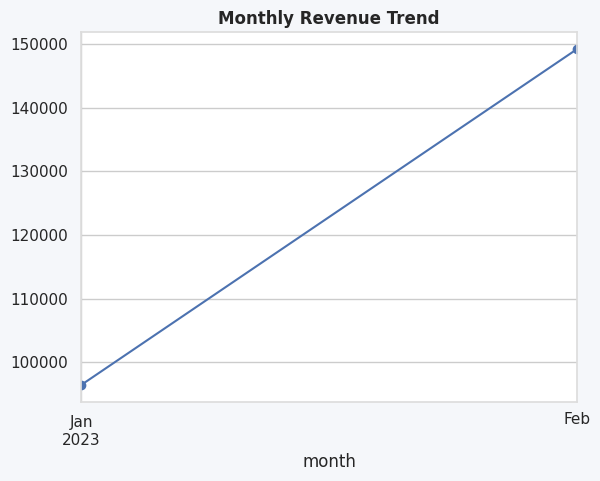

In [ ]:
df['month'] = df['admission_date'].dt.to_period('M')

monthly = df.groupby('month')['bill_amount'].sum()

plt.figure()
monthly.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.show()

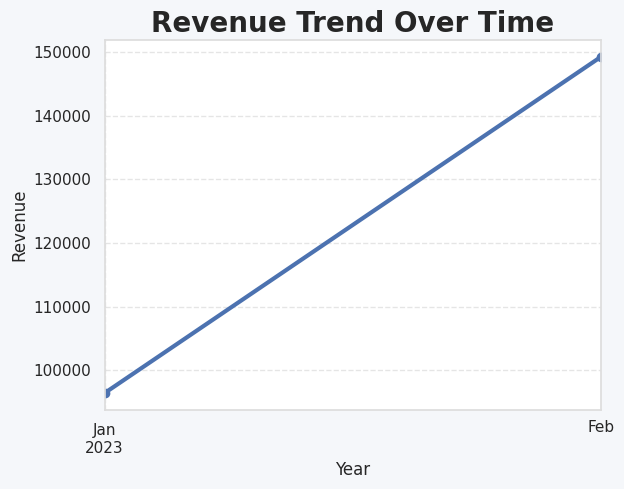

In [ ]:
monthly = df.groupby('month')['bill_amount'].sum()

plt.figure(facecolor='#f5f7fa')

ax = plt.gca()
ax.set_facecolor('#ffffff')

monthly.plot(marker='o', linewidth=3)

plt.title("Revenue Trend Over Time", fontsize=20, weight='bold')
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

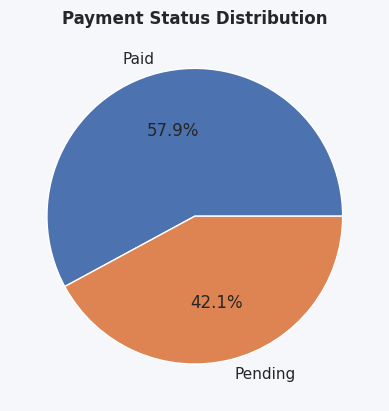

In [ ]:

df['payment_status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Status Distribution")
plt.ylabel("")
plt.show()

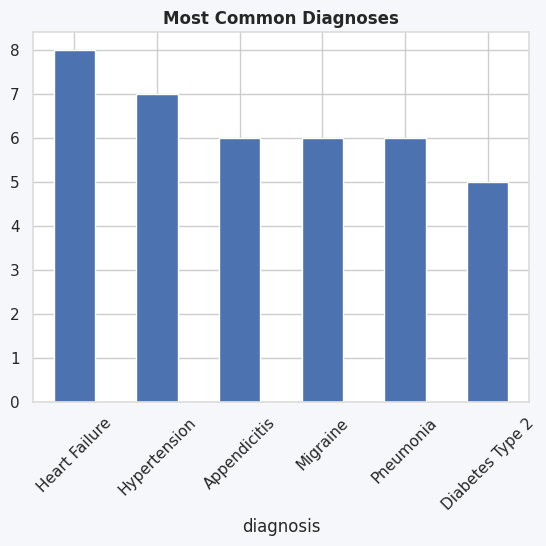

In [ ]:
plt.figure()
df['diagnosis'].value_counts().plot(kind='bar')
plt.title("Most Common Diagnoses")
plt.xticks(rotation=45)
plt.show()

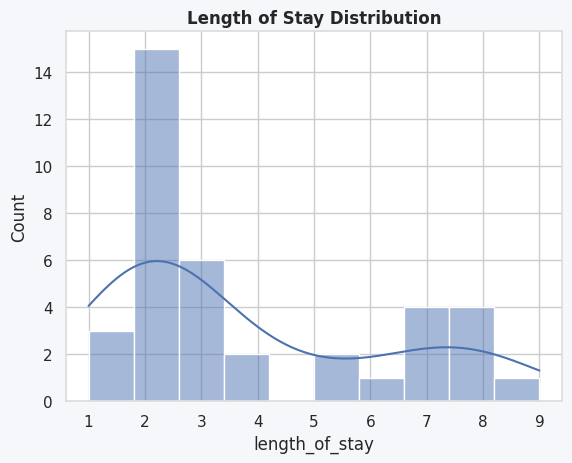

In [ ]:
plt.figure()
sns.histplot(df['length_of_stay'], bins=10, kde=True)
plt.title("Length of Stay Distribution")
plt.show()

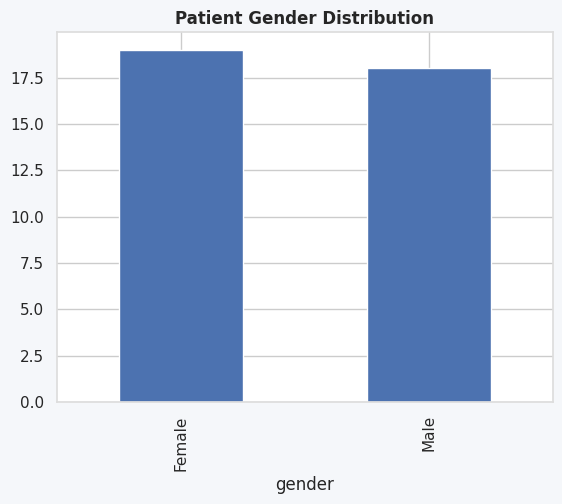

In [ ]:
df['gender'].value_counts().plot(kind='bar')
plt.title("Patient Gender Distribution")
plt.show()

In [ ]:
plt.savefig("revenue_trend.png")

<Figure size 640x480 with 0 Axes>

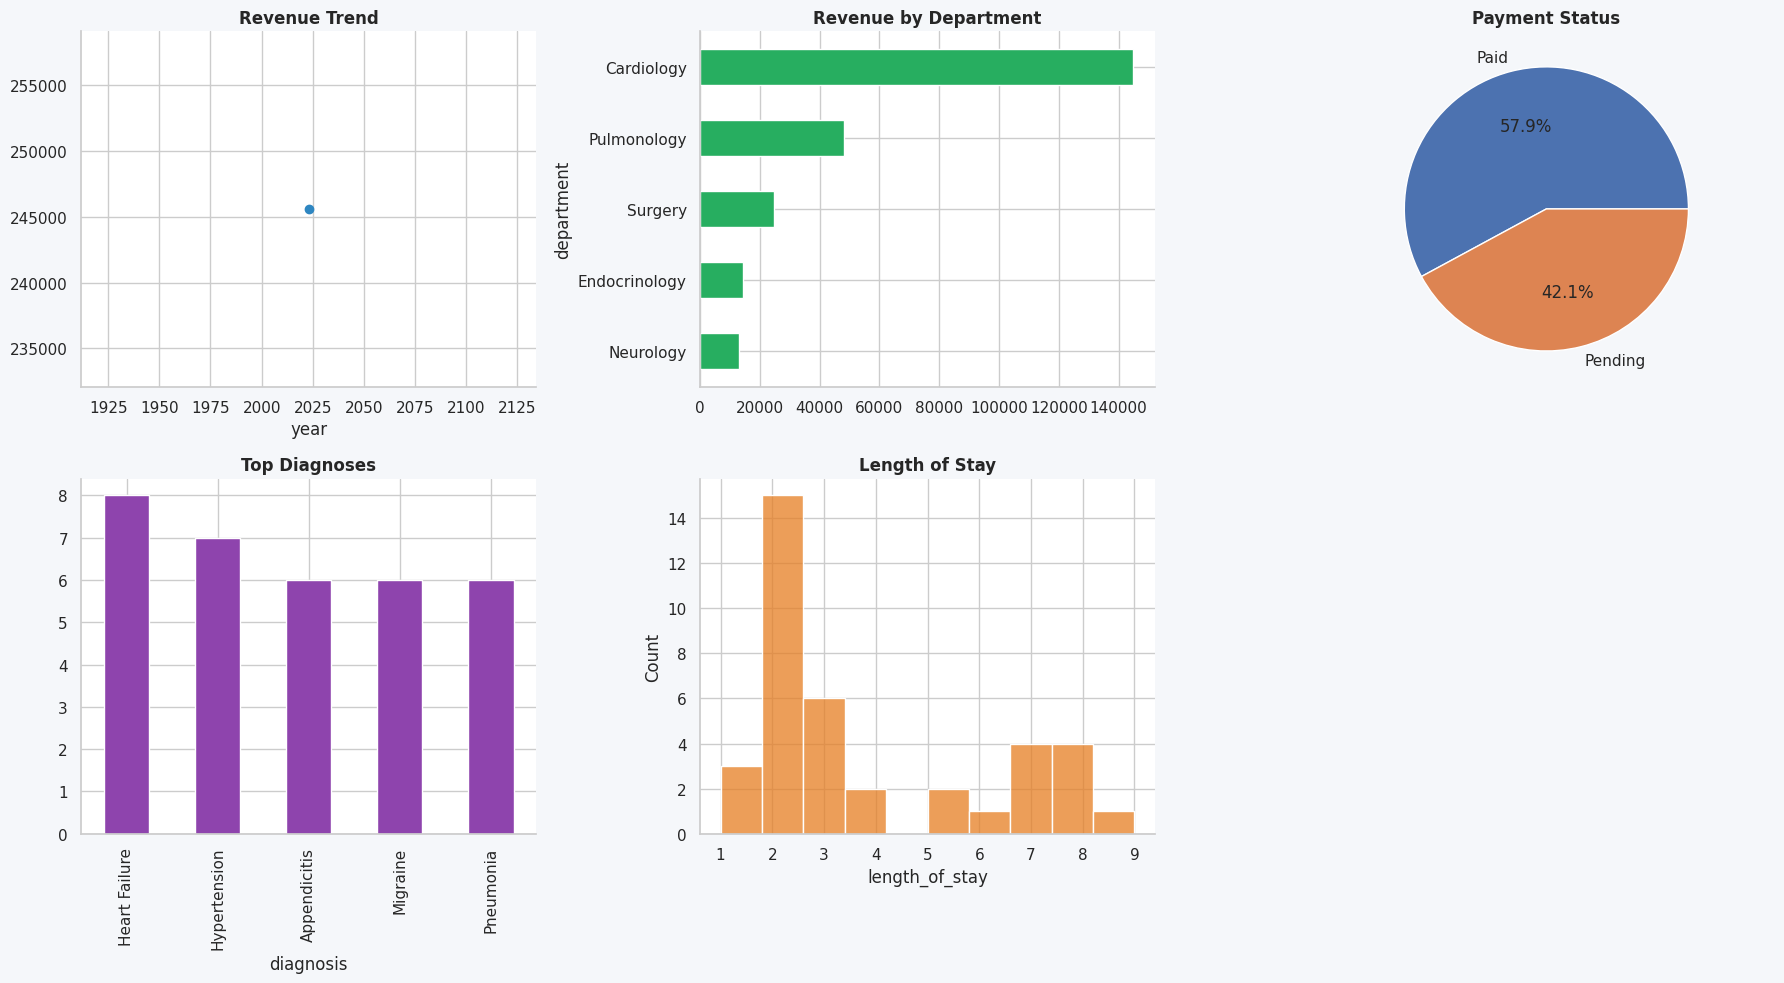

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("cleaned_hospital_data.csv")

df['admission_date'] = pd.to_datetime(df['admission_date'])
df['year'] = df['admission_date'].dt.year

# -----------------------------
# STYLE
# -----------------------------
sns.set_theme(style="whitegrid")

# -----------------------------
# CREATE FIGURE LAYOUT
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f5f7fa')

# -----------------------------
# 1. REVENUE TREND
# -----------------------------
yearly = df.groupby('year')['bill_amount'].sum()

axes[0, 0].set_facecolor('white')
yearly.plot(ax=axes[0, 0], marker='o', color='#2E86C1')
axes[0, 0].set_title("Revenue Trend")

# -----------------------------
# 2. REVENUE BY DEPARTMENT
# -----------------------------
dept = df.groupby('department')['bill_amount'].sum().sort_values()

axes[0, 1].set_facecolor('white')
dept.plot(kind='barh', ax=axes[0, 1], color='#27AE60')
axes[0, 1].set_title("Revenue by Department")

# -----------------------------
# 3. PAYMENT STATUS
# -----------------------------
axes[0, 2].set_facecolor('white')
df['payment_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0, 2]
)
axes[0, 2].set_title("Payment Status")
axes[0, 2].set_ylabel("")

# -----------------------------
# 4. DIAGNOSIS
# -----------------------------
axes[1, 0].set_facecolor('white')
df['diagnosis'].value_counts().head(5).plot(
    kind='bar',
    ax=axes[1, 0],
    color='#8E44AD'
)
axes[1, 0].set_title("Top Diagnoses")

# -----------------------------
# 5. LENGTH OF STAY
# -----------------------------
axes[1, 1].set_facecolor('white')
sns.histplot(df['length_of_stay'], bins=10, ax=axes[1, 1], color='#E67E22')
axes[1, 1].set_title("Length of Stay")

# -----------------------------
# REMOVE EMPTY PLOT
# -----------------------------
axes[1, 2].axis('off')

# -----------------------------
# FINAL TOUCH
# -----------------------------
plt.tight_layout()
sns.despine()

plt.show()

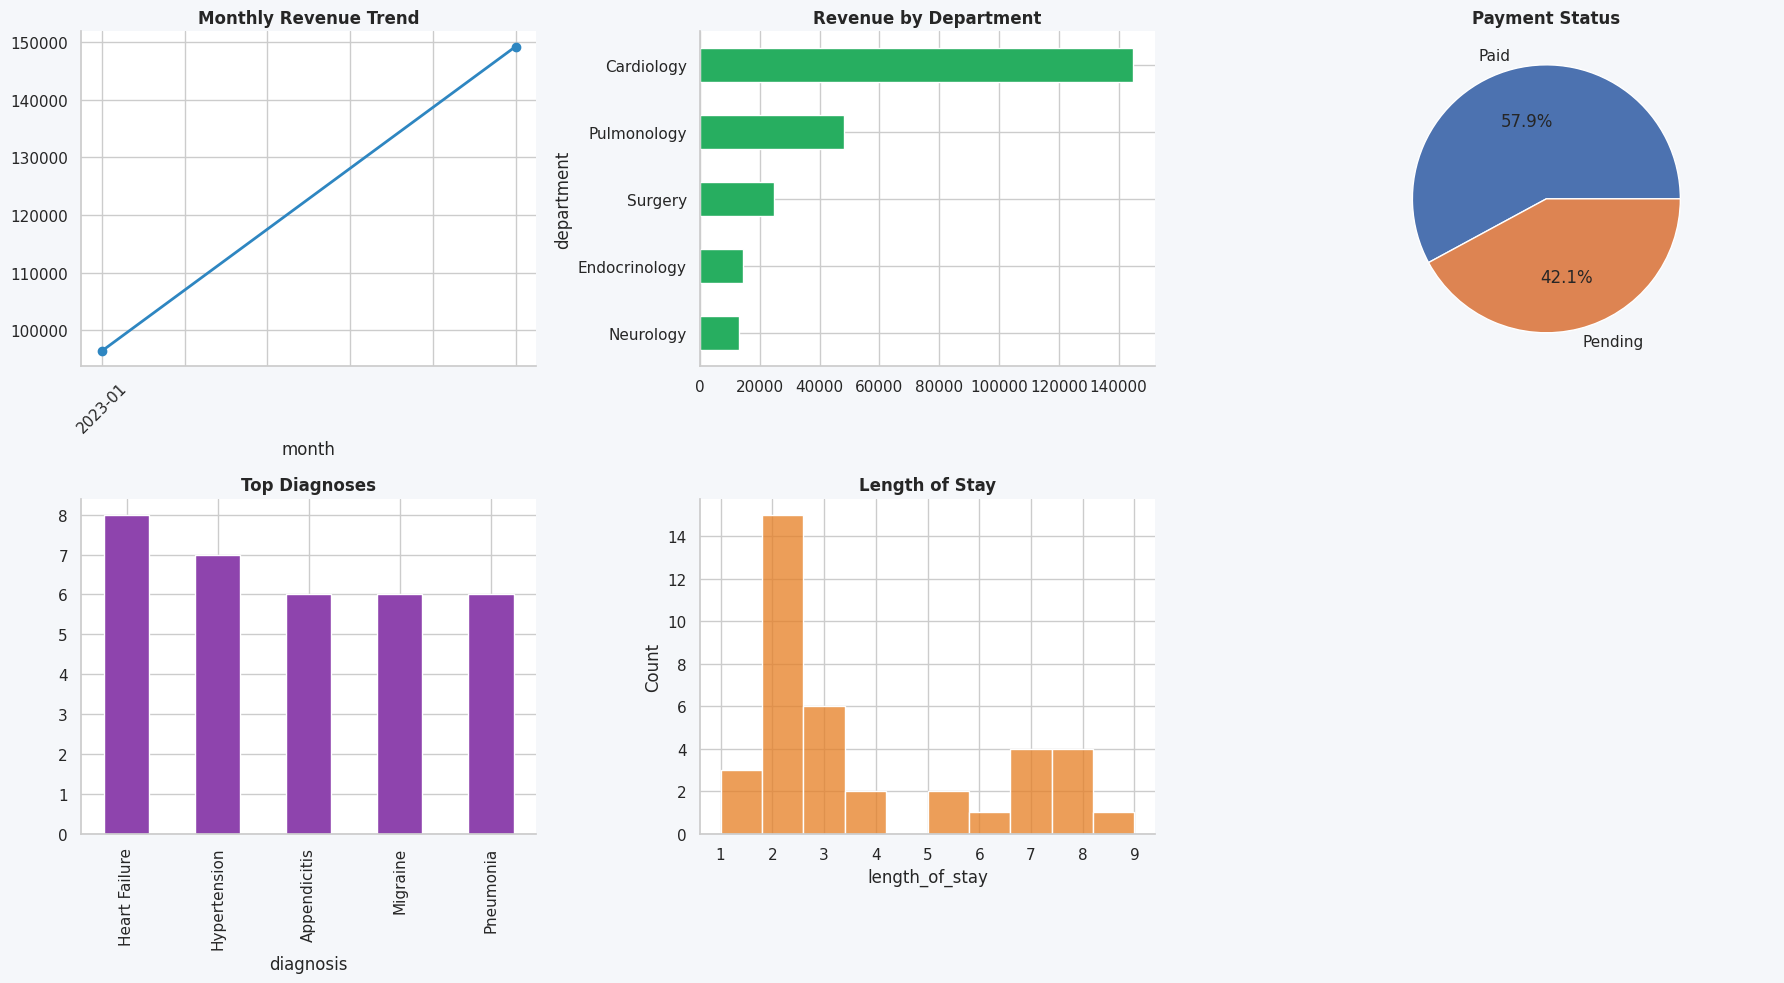

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("cleaned_hospital_data.csv")

df['admission_date'] = pd.to_datetime(df['admission_date'])

# -----------------------------
# CREATE MONTH COLUMN
# -----------------------------
df['month'] = df['admission_date'].dt.to_period('M')

# -----------------------------
# MONTHLY REVENUE
# -----------------------------
monthly = df.groupby('month')['bill_amount'].sum()

# convert index for plotting
monthly.index = monthly.index.astype(str)

# -----------------------------
# STYLE
# -----------------------------
sns.set_theme(style="whitegrid")

# -----------------------------
# CREATE DASHBOARD LAYOUT
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f5f7fa')

# -----------------------------
# 1. MONTHLY REVENUE TREND
# -----------------------------
axes[0, 0].set_facecolor('white')
monthly.plot(ax=axes[0, 0], marker='o', color='#2E86C1', linewidth=2)
axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].tick_params(axis='x', rotation=45)

# -----------------------------
# 2. REVENUE BY DEPARTMENT
# -----------------------------
dept = df.groupby('department')['bill_amount'].sum().sort_values()

axes[0, 1].set_facecolor('white')
dept.plot(kind='barh', ax=axes[0, 1], color='#27AE60')
axes[0, 1].set_title("Revenue by Department")

# -----------------------------
# 3. PAYMENT STATUS
# -----------------------------
axes[0, 2].set_facecolor('white')
df['payment_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0, 2]
)
axes[0, 2].set_title("Payment Status")
axes[0, 2].set_ylabel("")

# -----------------------------
# 4. TOP DIAGNOSIS
# -----------------------------
axes[1, 0].set_facecolor('white')
df['diagnosis'].value_counts().head(5).plot(
    kind='bar',
    ax=axes[1, 0],
    color='#8E44AD'
)
axes[1, 0].set_title("Top Diagnoses")

# -----------------------------
# 5. LENGTH OF STAY
# -----------------------------
axes[1, 1].set_facecolor('white')
sns.histplot(df['length_of_stay'], bins=10, ax=axes[1, 1], color='#E67E22')
axes[1, 1].set_title("Length of Stay")

# -----------------------------
# REMOVE EMPTY PANEL
# -----------------------------
axes[1, 2].axis('off')

# -----------------------------
# FINAL TOUCH
# -----------------------------
plt.tight_layout()
sns.despine()

plt.show()

In [ ]:
plt.savefig("hospital_dashboard_monthly.png", dpi=300, bbox_inches='tight')

In [ ]:
!pip install streamlit


In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# PAGE CONFIG
# -----------------------------
st.set_page_config(page_title="Hospital Dashboard", layout="wide")

# -----------------------------
# LOAD DATA
# -----------------------------
@st.cache_data
def load_data():
    df = pd.read_csv("cleaned_hospital_data.csv")
    df['admission_date'] = pd.to_datetime(df['admission_date'])
    df['year'] = df['admission_date'].dt.year
    df['month'] = df['admission_date'].dt.to_period('M')
    return df

df = load_data()

# -----------------------------
# SIDEBAR FILTERS
# -----------------------------
st.sidebar.header("🔍 Filters")

department = st.sidebar.multiselect(
    "Department", df['department'].unique(),
    default=df['department'].unique()
)

gender = st.sidebar.multiselect(
    "Gender", df['gender'].unique(),
    default=df['gender'].unique()
)

year = st.sidebar.multiselect(
    "Year", df['year'].unique(),
    default=df['year'].unique()
)

# Apply filters
filtered_df = df[
    (df['department'].isin(department)) &
    (df['gender'].isin(gender)) &
    (df['year'].isin(year))
]

# -----------------------------
# KPI METRICS
# -----------------------------
st.title("🏥 Hospital Performance Dashboard")

col1, col2, col3, col4 = st.columns(4)

total_revenue = filtered_df['bill_amount'].sum()
total_patients = filtered_df.shape[0]
paid_revenue = filtered_df[filtered_df['payment_status']=='Paid']['bill_amount'].sum()
unpaid_revenue = filtered_df[filtered_df['payment_status']=='Unpaid']['bill_amount'].sum()

col1.metric("💰 Revenue", f"{total_revenue:,.0f}")
col2.metric("👥 Patients", total_patients)
col3.metric("✅ Paid", f"{paid_revenue:,.0f}")
col4.metric("❌ Unpaid", f"{unpaid_revenue:,.0f}")

# -----------------------------
# MONTHLY REVENUE + GROWTH
# -----------------------------
monthly = filtered_df.groupby('month')['bill_amount'].sum()
monthly.index = monthly.index.astype(str)

mom_growth = monthly.pct_change() * 100

# -----------------------------
# LAYOUT
# -----------------------------
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor('#f5f7fa')



# -----------------------------
# 2. MOM GROWTH
# -----------------------------
axes[0, 1].set_facecolor('white')
mom_growth.plot(ax=axes[0, 1], marker='o', color='#E74C3C')
axes[0, 1].set_title("MoM Growth (%)")

# -----------------------------
# 3. DEPARTMENT
# -----------------------------
dept = filtered_df.groupby('department')['bill_amount'].sum()

axes[1, 0].set_facecolor('white')
dept.plot(kind='bar', ax=axes[1, 0], color='#27AE60')
axes[1, 0].set_title("Revenue by Department")

# -----------------------------
# 4. PAYMENT
# -----------------------------
axes[1, 1].set_facecolor('white')
filtered_df['payment_status'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[1, 1]
)
axes[1, 1].set_title("Payment Status")
axes[1, 1].set_ylabel("")

plt.tight_layout()

# Show dashboard
st.pyplot(fig)

# -----------------------------
# DATA TABLE
# -----------------------------
st.subheader("📄 Data Preview")
st.dataframe(filtered_df)

2026-04-02 10:53:29.537 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:53:29.538 No runtime found, using MemoryCacheStorageManager
2026-04-02 10:53:29.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:53:29.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:53:29.546 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:53:29.548 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:53:29.549 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:53:29.552 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 10:53:29.553 Thread 'MainThread':

DeltaGenerator()

<Figure size 640x480 with 0 Axes>

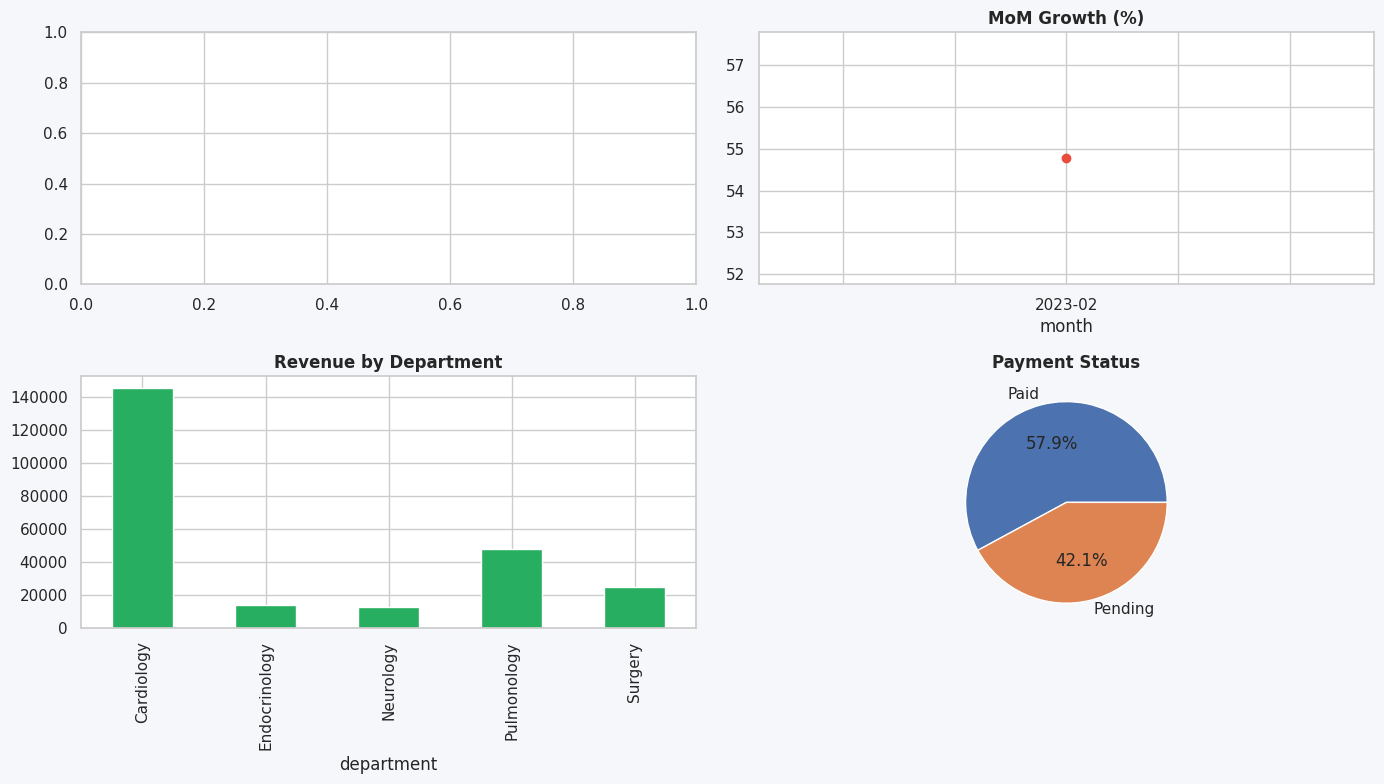

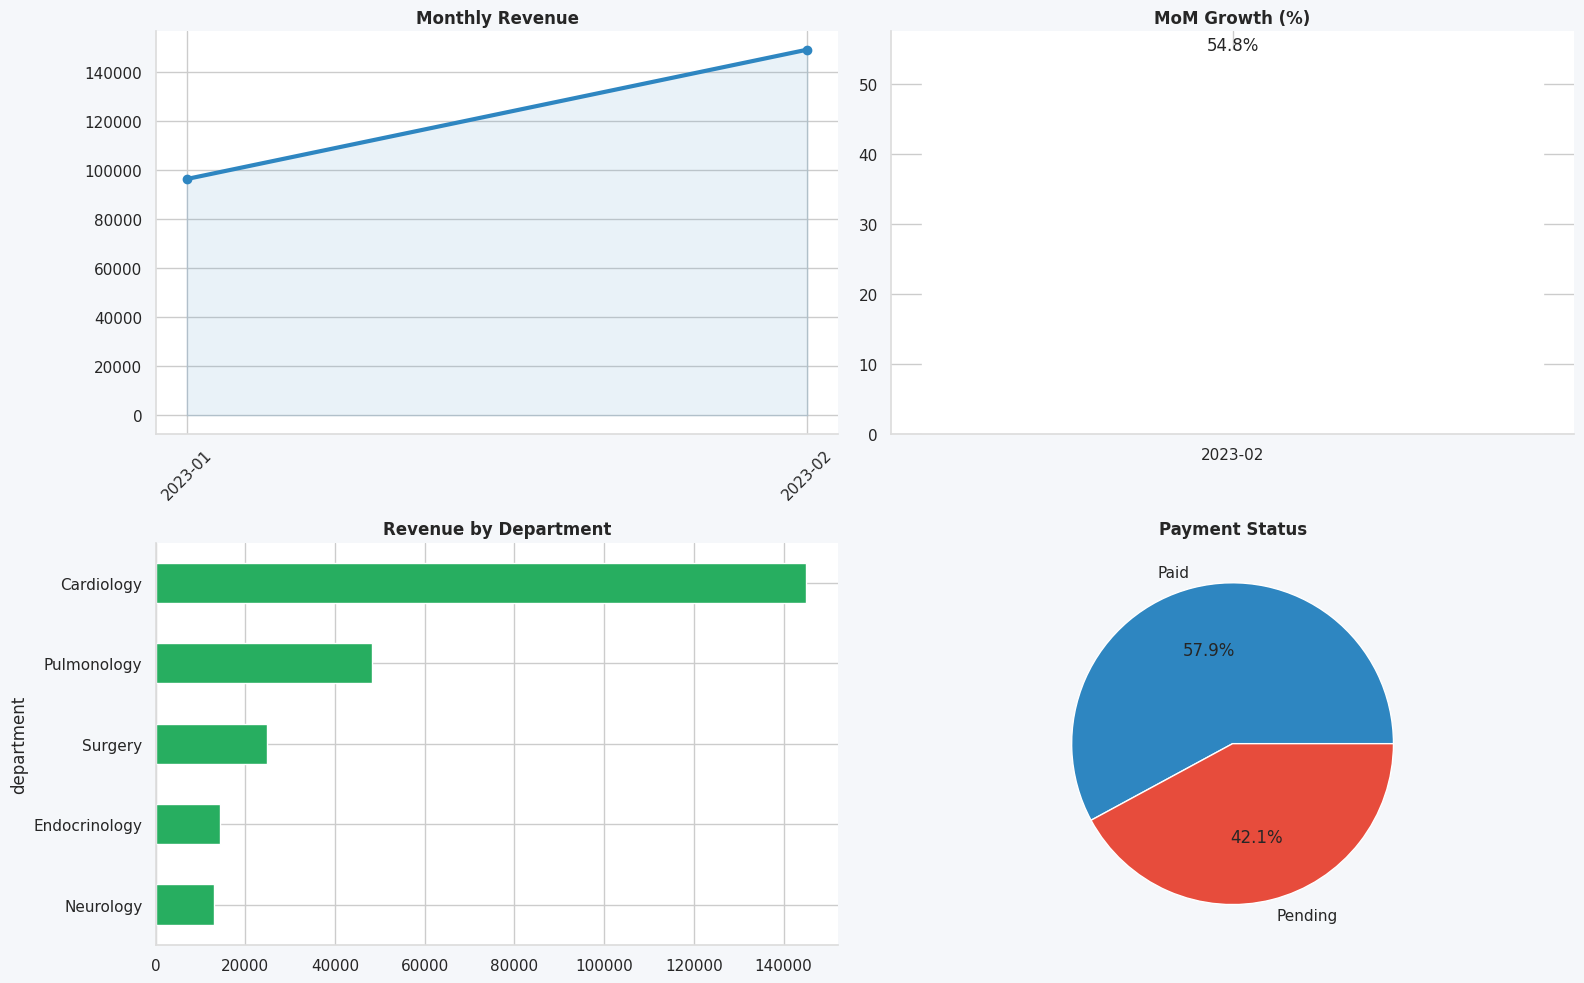

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("cleaned_hospital_data.csv")

df['admission_date'] = pd.to_datetime(df['admission_date'])

# -----------------------------
# CREATE TIME FEATURES
# -----------------------------
df['month'] = df['admission_date'].dt.to_period('M')

# -----------------------------
# AGGREGATIONS
# -----------------------------
monthly = df.groupby('month')['bill_amount'].sum()
monthly.index = monthly.index.astype(str)

mom_growth = monthly.pct_change() * 100
mom_growth = mom_growth.dropna()

dept = df.groupby('department')['bill_amount'].sum().sort_values()

# -----------------------------
# STYLE (PROFESSIONAL LOOK)
# -----------------------------
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    'figure.facecolor': '#f5f7fa',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#dddddd',
    'axes.titleweight': 'bold'
})

# -----------------------------
# CREATE DASHBOARD
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#f5f7fa')

# -----------------------------
# 1. MONTHLY REVENUE
# -----------------------------
axes[0, 0].set_facecolor('#ffffff')

axes[0, 0].plot(
    monthly.index,
    monthly.values,
    marker='o',
    linewidth=3,
    color='#2E86C1'
)

# Fill area (dashboard effect)
axes[0, 0].fill_between(
    monthly.index,
    monthly.values,
    color='#2E86C1',
    alpha=0.1
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].tick_params(axis='x', rotation=45)

# -----------------------------
# 2. MOM GROWTH (COLORED)
# -----------------------------
colors = ['white' if x > 0 else 'red' for x in mom_growth]

axes[0, 1].set_facecolor('#ffffff')

axes[0, 1].bar(
    mom_growth.index,
    mom_growth.values,
    color=colors
)

axes[0, 1].set_title("MoM Growth (%)")

# Add labels
for i, v in enumerate(mom_growth):
    axes[0, 1].text(i, v, f"{v:.1f}%", ha='center')

# -----------------------------
# 3. REVENUE BY DEPARTMENT
# -----------------------------
axes[1, 0].set_facecolor('#ffffff')

dept.plot(
    kind='barh',
    ax=axes[1, 0],
    color='#27AE60'
)

axes[1, 0].set_title("Revenue by Department")

# -----------------------------
# 4. PAYMENT STATUS
# -----------------------------
axes[1, 1].set_facecolor('#ffffff')

df['payment_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1, 1],
    colors=['#2E86C1', '#E74C3C']
)

axes[1, 1].set_title("Payment Status")
axes[1, 1].set_ylabel("")

# -----------------------------
# CLEAN LOOK
# -----------------------------
sns.despine()
plt.tight_layout()

# -----------------------------
# SAVE & SHOW
# -----------------------------
plt.savefig("hospital_dashboard_pro.png", dpi=300, bbox_inches='tight')
plt.show()

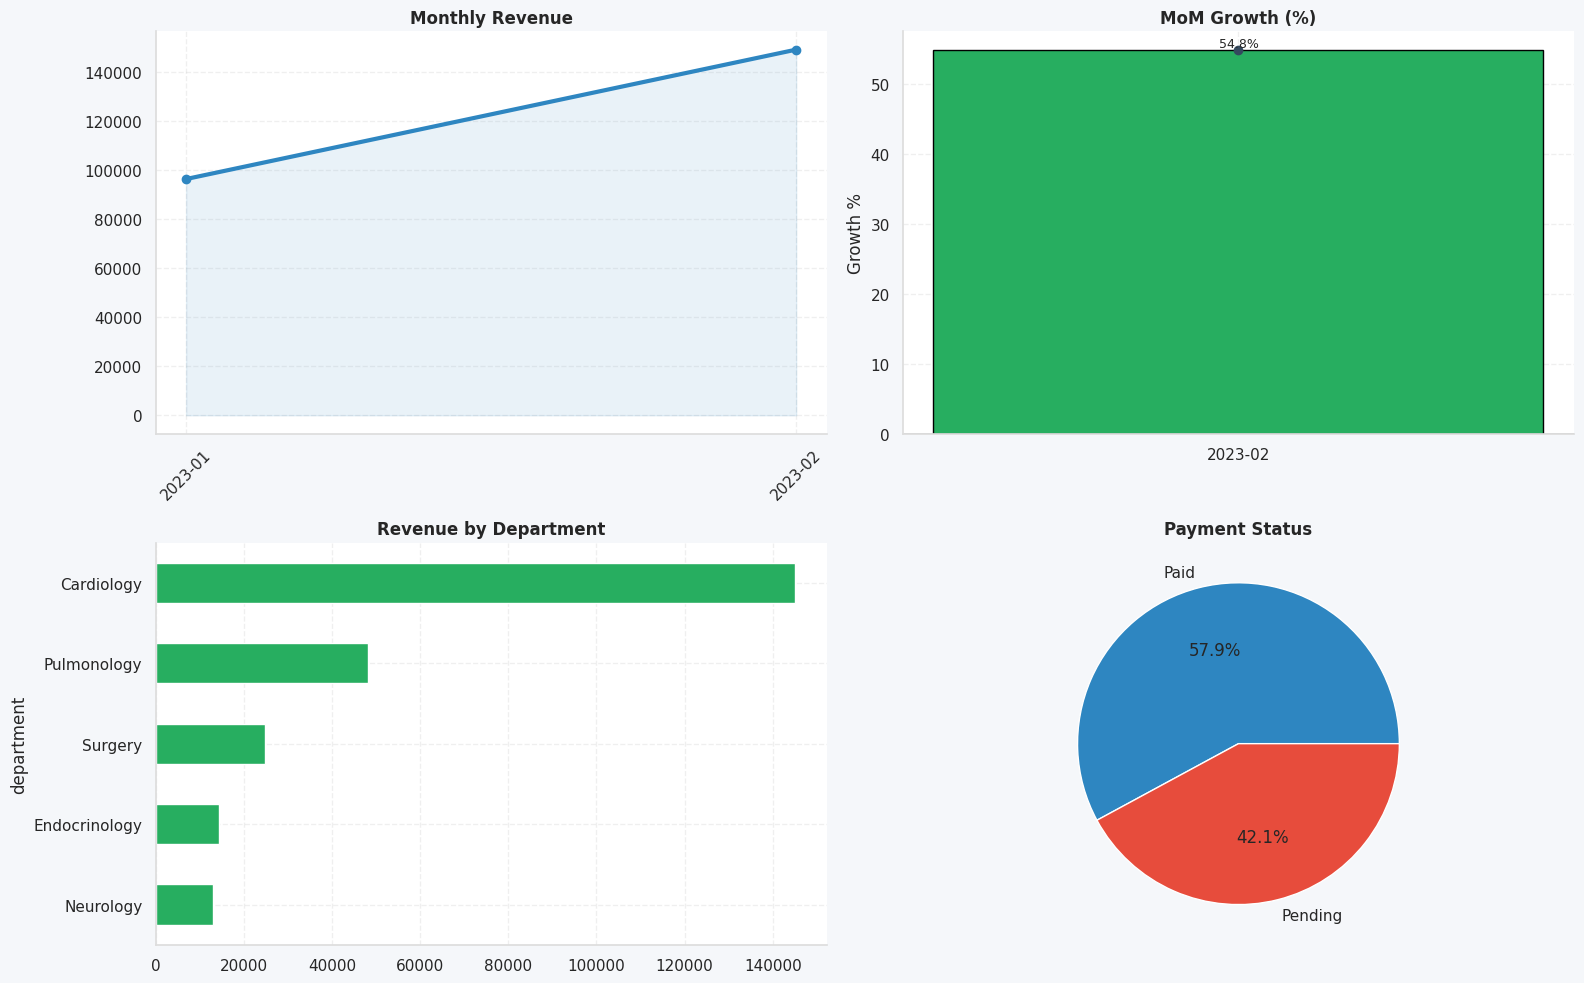

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("cleaned_hospital_data.csv")
df['admission_date'] = pd.to_datetime(df['admission_date'])

# -----------------------------
# CREATE TIME FEATURES
# -----------------------------
df['month'] = df['admission_date'].dt.to_period('M')

# -----------------------------
# AGGREGATIONS
# -----------------------------
monthly = df.groupby('month')['bill_amount'].sum()
monthly.index = monthly.index.astype(str)

mom_growth = monthly.pct_change() * 100
mom_growth = mom_growth.dropna()

dept = df.groupby('department')['bill_amount'].sum().sort_values()

# -----------------------------
# STYLE (PROFESSIONAL)
# -----------------------------
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    'figure.facecolor': '#f5f7fa',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#dddddd',
    'axes.titleweight': 'bold'
})

# -----------------------------
# CREATE DASHBOARD
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#f5f7fa')

# -----------------------------
# 1. MONTHLY REVENUE
# -----------------------------
axes[0, 0].set_facecolor('#ffffff')

axes[0, 0].plot(
    monthly.index,
    monthly.values,
    marker='o',
    linewidth=3,
    color='#2E86C1'
)

axes[0, 0].fill_between(
    monthly.index,
    monthly.values,
    color='#2E86C1',
    alpha=0.1
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

# -----------------------------
# 2. MOM GROWTH (FIXED 🔥)
# -----------------------------
axes[0, 1].set_facecolor('#ffffff')

# Color logic
colors = ['#27AE60' if x > 0 else '#E74C3C' for x in mom_growth]

bars = axes[0, 1].bar(
    mom_growth.index,
    mom_growth.values,
    color=colors,
    edgecolor='black'
)

# Add trend line
axes[0, 1].plot(
    mom_growth.index,
    mom_growth.values,
    color='#34495E',
    marker='o',
    linewidth=2
)

axes[0, 1].set_title("MoM Growth (%)")
axes[0, 1].set_ylabel("Growth %")

# Add zero line
axes[0, 1].axhline(0, color='black', linewidth=1)

# Add labels
for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha='center',
        va='bottom' if height > 0 else 'top',
        fontsize=9
    )

axes[0, 1].grid(True, linestyle='--', alpha=0.3)

# -----------------------------
# 3. REVENUE BY DEPARTMENT
# -----------------------------
axes[1, 0].set_facecolor('#ffffff')

dept.plot(
    kind='barh',
    ax=axes[1, 0],
    color='#27AE60'
)

axes[1, 0].set_title("Revenue by Department")
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

# -----------------------------
# 4. PAYMENT STATUS
# -----------------------------
axes[1, 1].set_facecolor('#ffffff')

df['payment_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1, 1],
    colors=['#2E86C1', '#E74C3C']
)

axes[1, 1].set_title("Payment Status")
axes[1, 1].set_ylabel("")

# -----------------------------
# CLEAN LOOK
# -----------------------------
sns.despine()
plt.tight_layout()

# -----------------------------
# SAVE & SHOW
# -----------------------------
plt.savefig("hospital_dashboard_pro.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_710/830957018.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_710/830957018.py:137: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




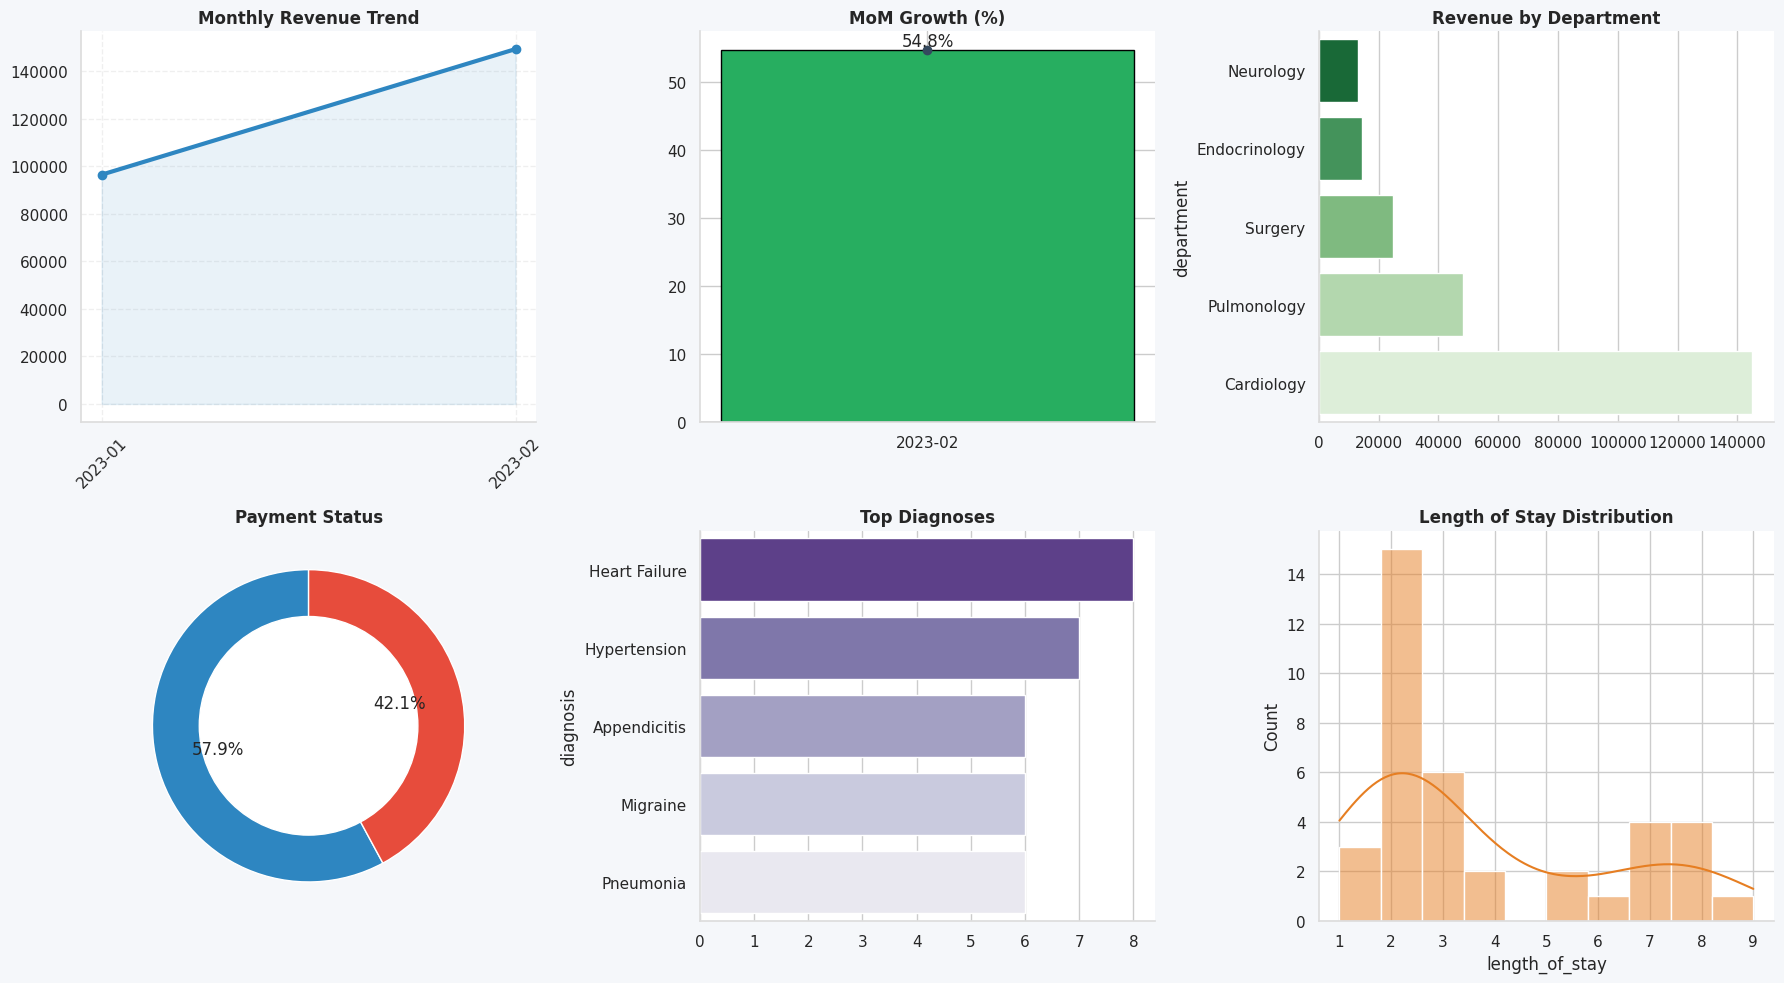

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("cleaned_hospital_data.csv")
df['admission_date'] = pd.to_datetime(df['admission_date'])

# -----------------------------
# CREATE TIME FEATURES
# -----------------------------
df['month'] = df['admission_date'].dt.to_period('M')

# -----------------------------
# AGGREGATIONS
# -----------------------------
monthly = df.groupby('month')['bill_amount'].sum()
monthly.index = monthly.index.astype(str)

mom_growth = monthly.pct_change() * 100
mom_growth = mom_growth.dropna()

dept = df.groupby('department')['bill_amount'].sum().sort_values()

diagnosis = df['diagnosis'].value_counts().head(5)

# -----------------------------
# STYLE
# -----------------------------
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    'figure.facecolor': '#f5f7fa',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#dddddd',
    'axes.titleweight': 'bold'
})

# -----------------------------
# CREATE DASHBOARD (2x3 GRID 🔥)
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f5f7fa')

# -----------------------------
# 1. MONTHLY REVENUE (IMPROVED)
# -----------------------------
axes[0, 0].plot(
    monthly.index,
    monthly.values,
    marker='o',
    linewidth=3,
    color='#2E86C1'
)

axes[0, 0].fill_between(
    monthly.index,
    monthly.values,
    color='#2E86C1',
    alpha=0.1
)

axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

# -----------------------------
# 2. MOM GROWTH (ENHANCED 🔥)
# -----------------------------
colors = ['#27AE60' if x > 0 else '#E74C3C' for x in mom_growth]

bars = axes[0, 1].bar(
    mom_growth.index,
    mom_growth.values,
    color=colors,
    edgecolor='black'
)

# Trend line
axes[0, 1].plot(
    mom_growth.index,
    mom_growth.values,
    color='#34495E',
    marker='o',
    linewidth=2
)

axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title("MoM Growth (%)")

# Labels
for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha='center',
        va='bottom' if height > 0 else 'top'
    )

# -----------------------------
# 3. REVENUE BY DEPARTMENT
# -----------------------------
sns.barplot(
    x=dept.values,
    y=dept.index,
    ax=axes[0, 2],
    palette="Greens_r"
)

axes[0, 2].set_title("Revenue by Department")

# -----------------------------
# 4. PAYMENT STATUS (DONUT 🔥)
# -----------------------------
payment = df['payment_status'].value_counts()

wedges, texts, autotexts = axes[1, 0].pie(
    payment,
    autopct='%1.1f%%',
    colors=['#2E86C1', '#E74C3C'],
    startangle=90
)

# Donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
axes[1, 0].add_artist(centre_circle)

axes[1, 0].set_title("Payment Status")

# -----------------------------
# 5. TOP DIAGNOSES (NEW 🔥)
# -----------------------------
sns.barplot(
    x=diagnosis.values,
    y=diagnosis.index,
    ax=axes[1, 1],
    palette="Purples_r"
)

axes[1, 1].set_title("Top Diagnoses")

# -----------------------------
# 6. LENGTH OF STAY (IMPROVED)
# -----------------------------
sns.histplot(
    df['length_of_stay'],
    bins=10,
    kde=True,
    ax=axes[1, 2],
    color='#E67E22'
)

axes[1, 2].set_title("Length of Stay Distribution")

# -----------------------------
# CLEAN LOOK
# -----------------------------
sns.despine()
plt.tight_layout()

# -----------------------------
# SAVE & SHOW
# -----------------------------
plt.savefig("hospital_dashboard_pro_plus.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_710/1595076837.py:68: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_710/1595076837.py:97: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




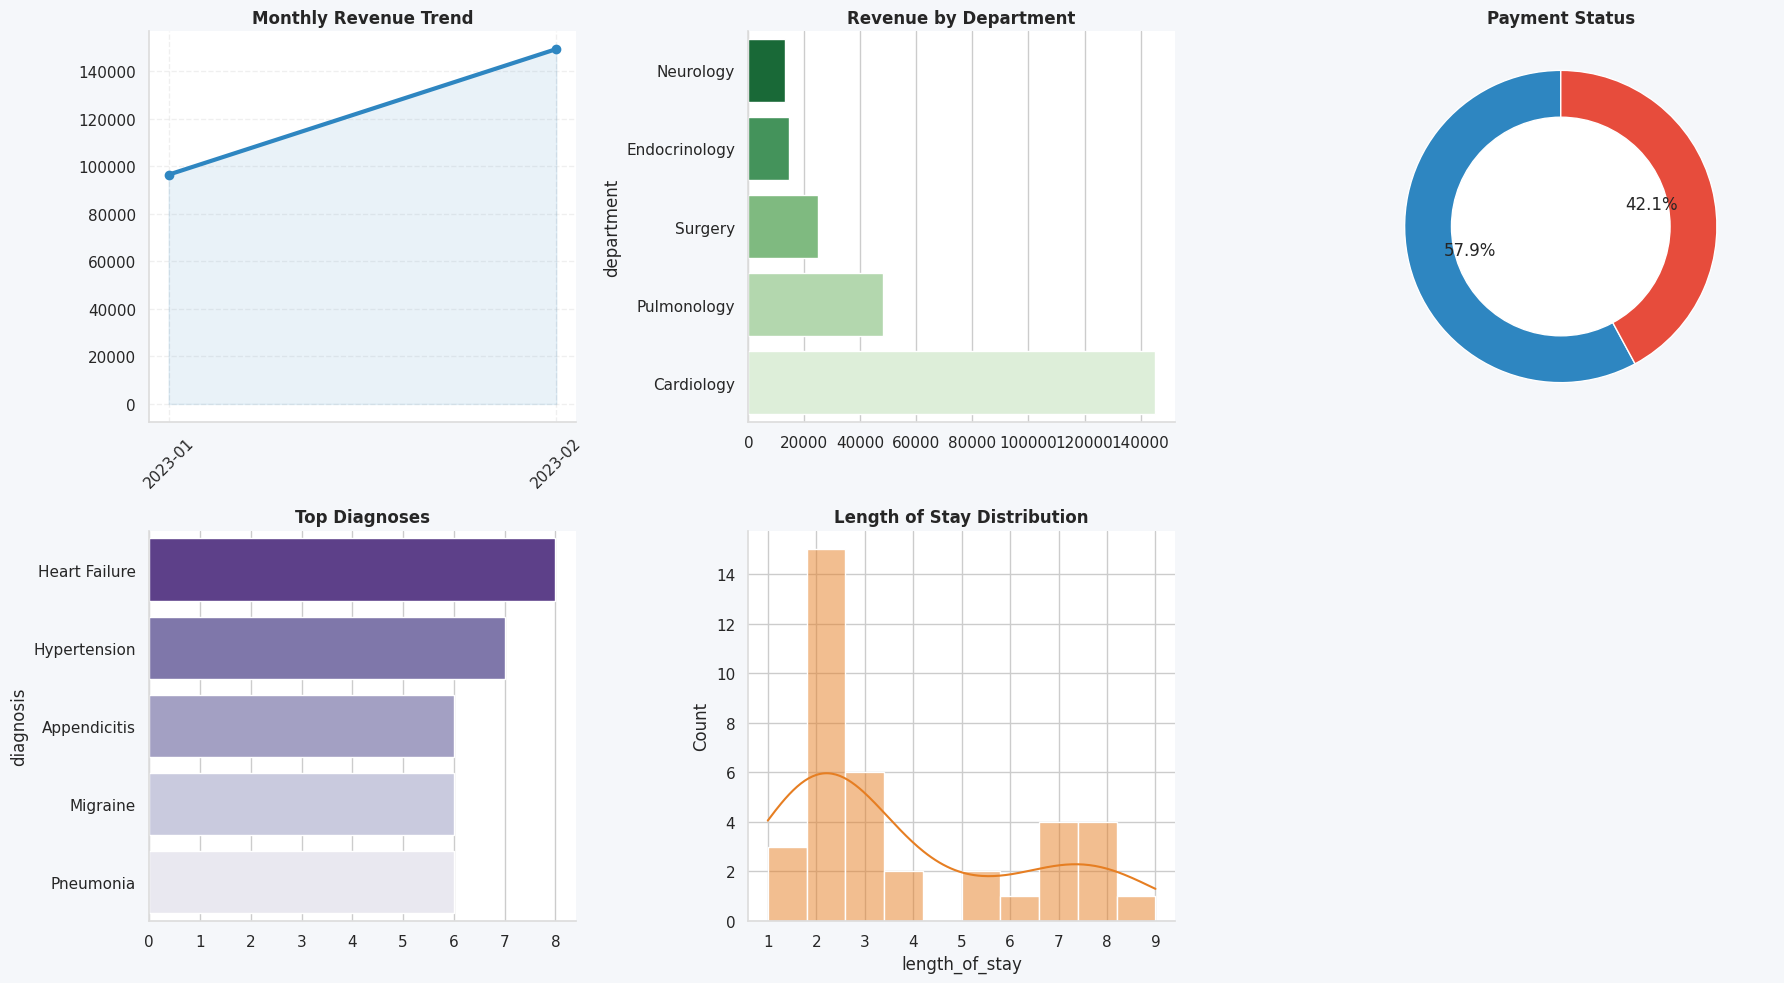

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("cleaned_hospital_data.csv")
df['admission_date'] = pd.to_datetime(df['admission_date'])

# -----------------------------
# CREATE TIME FEATURES
# -----------------------------
df['month'] = df['admission_date'].dt.to_period('M')

# -----------------------------
# AGGREGATIONS
# -----------------------------
monthly = df.groupby('month')['bill_amount'].sum()
monthly.index = monthly.index.astype(str)

dept = df.groupby('department')['bill_amount'].sum().sort_values()
diagnosis = df['diagnosis'].value_counts().head(5)

# -----------------------------
# STYLE (PROFESSIONAL)
# -----------------------------
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    'figure.facecolor': '#f5f7fa',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#dddddd',
    'axes.titleweight': 'bold'
})

# -----------------------------
# CREATE DASHBOARD (2x3 GRID)
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f5f7fa')

# -----------------------------
# 1. MONTHLY REVENUE
# -----------------------------
axes[0, 0].plot(
    monthly.index,
    monthly.values,
    marker='o',
    linewidth=3,
    color='#2E86C1'
)

axes[0, 0].fill_between(
    monthly.index,
    monthly.values,
    color='#2E86C1',
    alpha=0.1
)

axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

# -----------------------------
# 2. REVENUE BY DEPARTMENT
# -----------------------------
sns.barplot(
    x=dept.values,
    y=dept.index,
    ax=axes[0, 1],
    palette="Greens_r"
)

axes[0, 1].set_title("Revenue by Department")

# -----------------------------
# 3. PAYMENT STATUS (DONUT)
# -----------------------------
payment = df['payment_status'].value_counts()

wedges, texts, autotexts = axes[0, 2].pie(
    payment,
    autopct='%1.1f%%',
    colors=['#2E86C1', '#E74C3C'],
    startangle=90
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
axes[0, 2].add_artist(centre_circle)

axes[0, 2].set_title("Payment Status")

# -----------------------------
# 4. TOP DIAGNOSES
# -----------------------------
sns.barplot(
    x=diagnosis.values,
    y=diagnosis.index,
    ax=axes[1, 0],
    palette="Purples_r"
)

axes[1, 0].set_title("Top Diagnoses")

# -----------------------------
# 5. LENGTH OF STAY
# -----------------------------
sns.histplot(
    df['length_of_stay'],
    bins=10,
    kde=True,
    ax=axes[1, 1],
    color='#E67E22'
)

axes[1, 1].set_title("Length of Stay Distribution")

# -----------------------------
# REMOVE EMPTY SPACE
# -----------------------------
axes[1, 2].axis('off')

# -----------------------------
# CLEAN LOOK
# -----------------------------
sns.despine()
plt.tight_layout()

# -----------------------------
# SAVE & SHOW
# -----------------------------
plt.savefig("hospital_dashboard_final.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_710/876413763.py:75: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_710/876413763.py:105: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




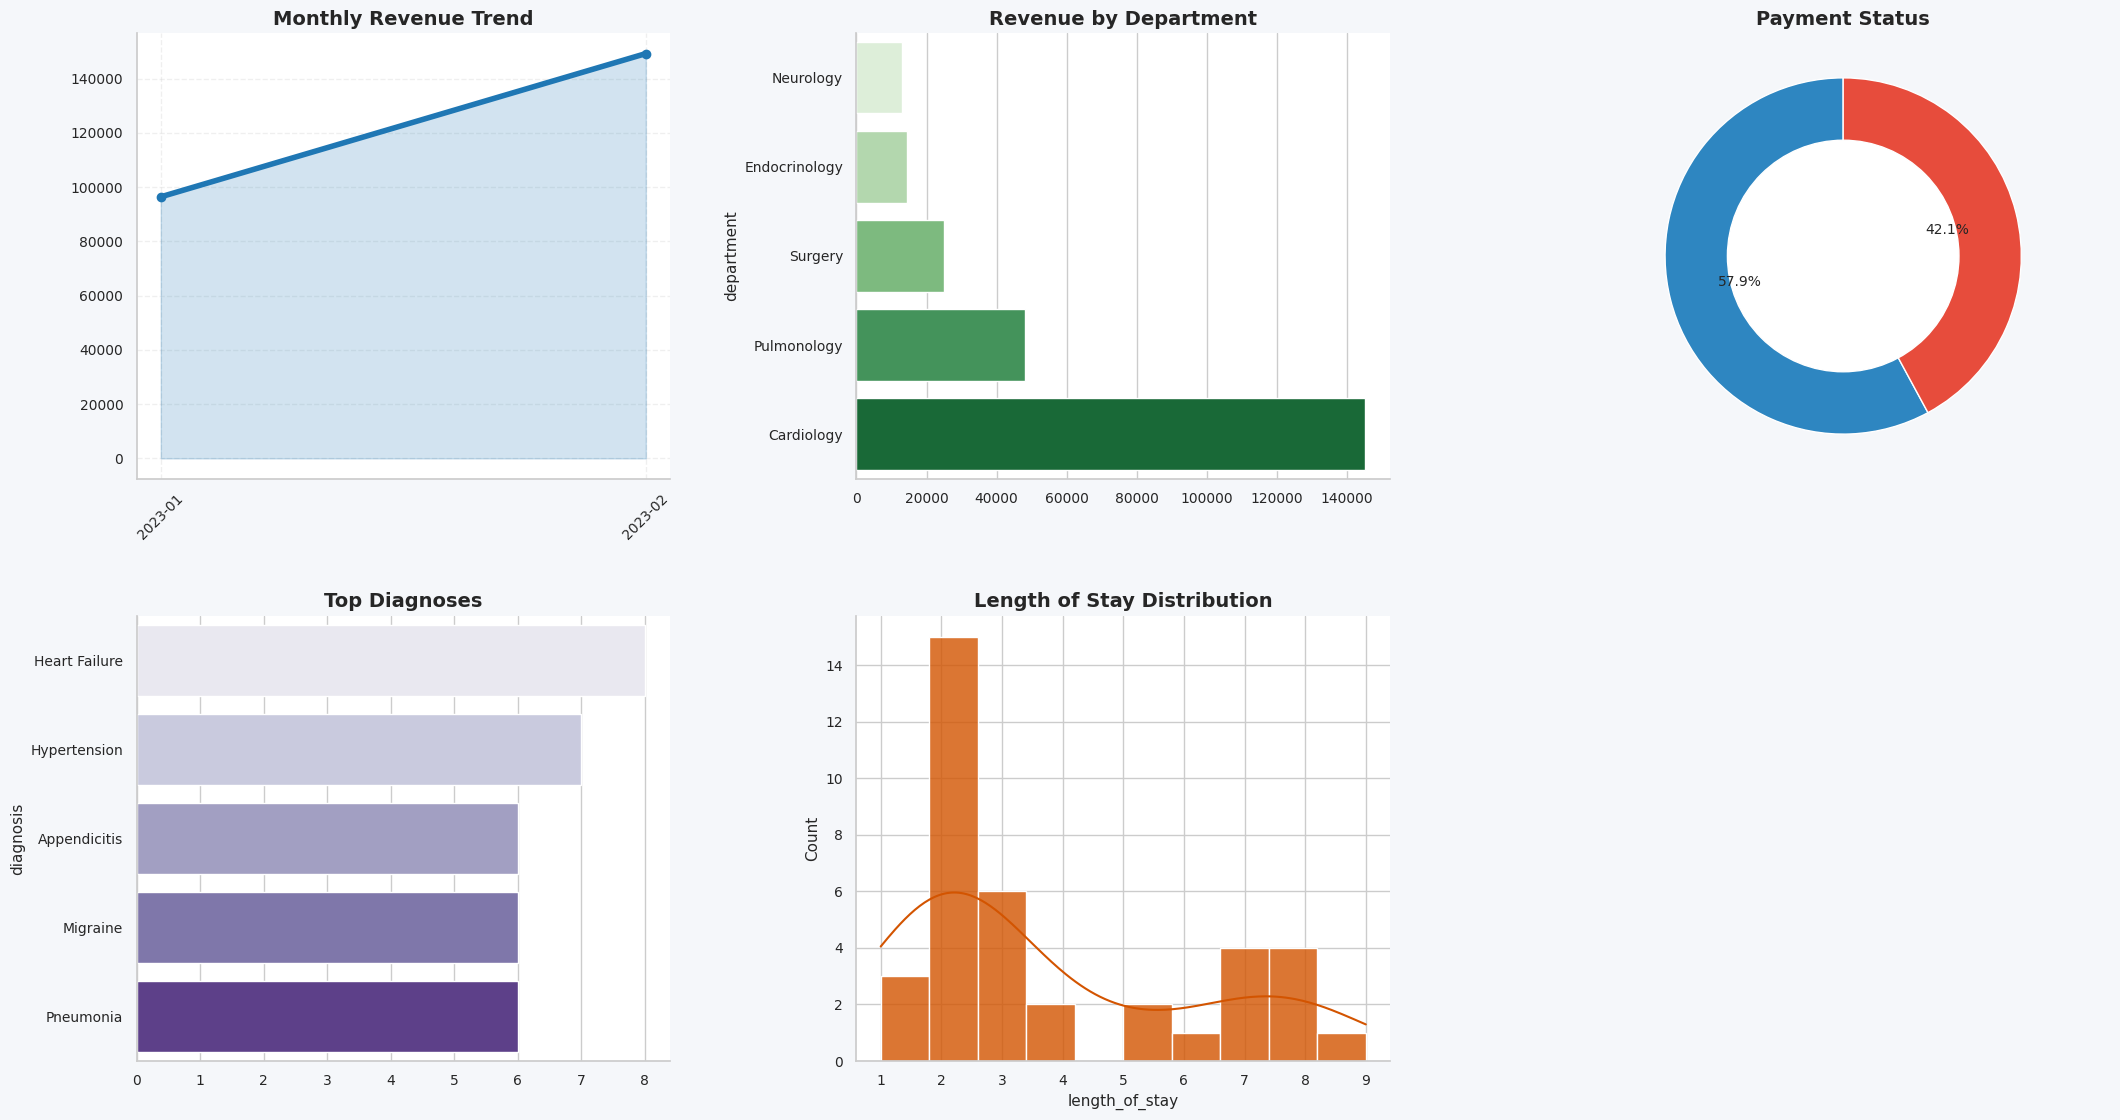

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("cleaned_hospital_data.csv")
df['admission_date'] = pd.to_datetime(df['admission_date'])

# -----------------------------
# CREATE TIME FEATURES
# -----------------------------
df['month'] = df['admission_date'].dt.to_period('M')

# -----------------------------
# AGGREGATIONS
# -----------------------------
monthly = df.groupby('month')['bill_amount'].sum()
monthly.index = monthly.index.astype(str)

dept = df.groupby('department')['bill_amount'].sum().sort_values()
diagnosis = df['diagnosis'].value_counts().head(5)

# -----------------------------
# STYLE (UPGRADED 🔥)
# -----------------------------
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    'figure.facecolor': '#f5f7fa',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#cccccc',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# -----------------------------
# BIGGER DASHBOARD (KEY FIX 🔥)
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor('#f5f7fa')

# Better spacing
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# -----------------------------
# 1. MONTHLY REVENUE (STRONGER)
# -----------------------------
axes[0, 0].plot(
    monthly.index,
    monthly.values,
    marker='o',
    linewidth=4,
    color='#1f77b4'
)

axes[0, 0].fill_between(
    monthly.index,
    monthly.values,
    color='#1f77b4',
    alpha=0.2
)

axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

# -----------------------------
# 2. REVENUE BY DEPARTMENT
# -----------------------------
sns.barplot(
    x=dept.values,
    y=dept.index,
    ax=axes[0, 1],
    palette="Greens"
)

axes[0, 1].set_title("Revenue by Department")

# -----------------------------
# 3. PAYMENT STATUS (DONUT)
# -----------------------------
payment = df['payment_status'].value_counts()

wedges, texts, autotexts = axes[0, 2].pie(
    payment,
    autopct='%1.1f%%',
    colors=['#2E86C1', '#E74C3C'],
    startangle=90,
    textprops={'fontsize': 10}
)

centre_circle = plt.Circle((0, 0), 0.65, fc='white')
axes[0, 2].add_artist(centre_circle)

axes[0, 2].set_title("Payment Status")

# -----------------------------
# 4. TOP DIAGNOSES
# -----------------------------
sns.barplot(
    x=diagnosis.values,
    y=diagnosis.index,
    ax=axes[1, 0],
    palette="Purples"
)

axes[1, 0].set_title("Top Diagnoses")

# -----------------------------
# 5. LENGTH OF STAY
# -----------------------------
sns.histplot(
    df['length_of_stay'],
    bins=10,
    kde=True,
    ax=axes[1, 1],
    color='#d35400',
    alpha=0.8
)

axes[1, 1].set_title("Length of Stay Distribution")

# -----------------------------
# REMOVE EMPTY PANEL
# -----------------------------
axes[1, 2].axis('off')

# -----------------------------
# CLEAN LOOK
# -----------------------------
sns.despine()

plt.tight_layout(pad=3.0)

# -----------------------------
# SAVE & SHOW
# -----------------------------
plt.savefig(
    "hospital_dashboard_final.png",
    dpi=400,
    bbox_inches='tight'
)

plt.show()

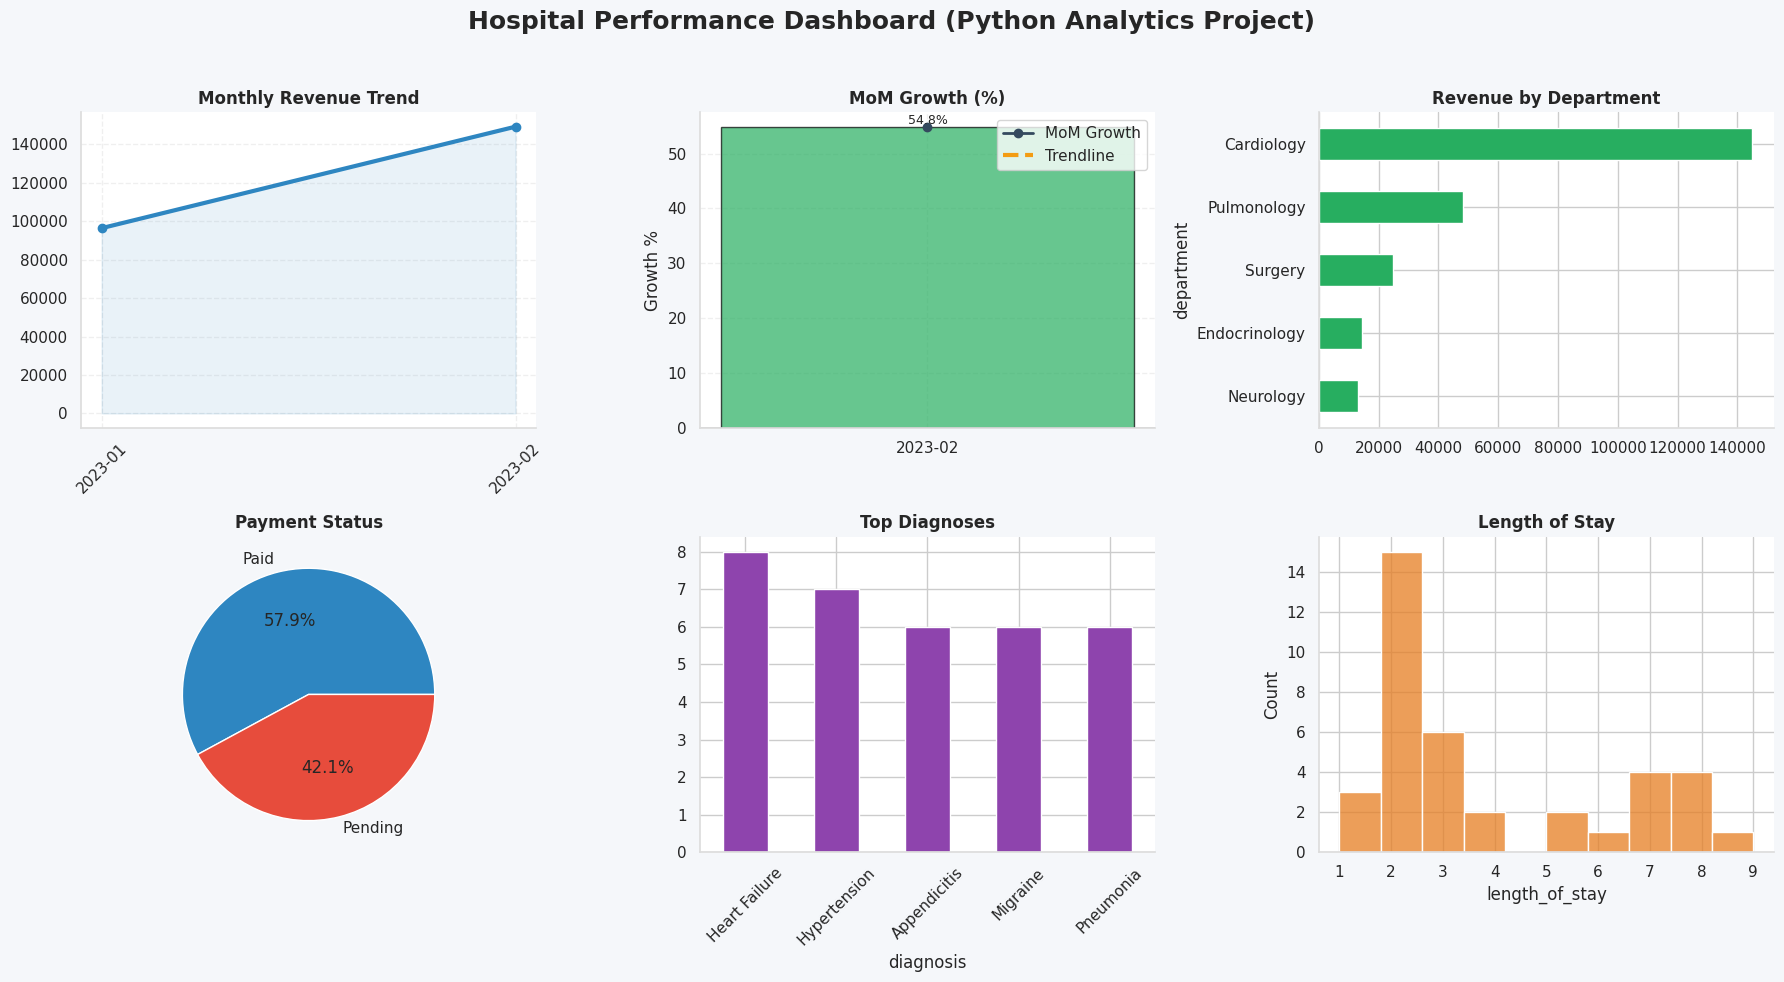

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("cleaned_hospital_data.csv")
df['admission_date'] = pd.to_datetime(df['admission_date'])

# -----------------------------
# CREATE TIME FEATURES
# -----------------------------
df['month'] = df['admission_date'].dt.to_period('M')

# -----------------------------
# AGGREGATIONS
# -----------------------------
monthly = df.groupby('month')['bill_amount'].sum()
monthly.index = monthly.index.astype(str)

mom_growth = monthly.pct_change() * 100
mom_growth = mom_growth.dropna()

# 🔥 NEW: Moving Average Trendline
mom_trend = mom_growth.rolling(window=2).mean()

dept = df.groupby('department')['bill_amount'].sum().sort_values()
diagnosis = df['diagnosis'].value_counts().head(5)

# -----------------------------
# STYLE (PROFESSIONAL)
# -----------------------------
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    'figure.facecolor': '#f5f7fa',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#dddddd',
    'axes.titleweight': 'bold'
})

# -----------------------------
# CREATE DASHBOARD
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f5f7fa')

# -----------------------------
# 🔥 PROJECT TITLE
# -----------------------------
fig.suptitle(
    "Hospital Performance Dashboard (Python Analytics Project)",
    fontsize=18,
    fontweight='bold'
)

# -----------------------------
# 1. MONTHLY REVENUE
# -----------------------------
axes[0, 0].plot(
    monthly.index,
    monthly.values,
    marker='o',
    linewidth=3,
    color='#2E86C1'
)

axes[0, 0].fill_between(
    monthly.index,
    monthly.values,
    color='#2E86C1',
    alpha=0.1
)

axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

# -----------------------------
# 2. MOM GROWTH + TRENDLINE
# -----------------------------
axes[0, 1].set_facecolor('#ffffff')

colors = ['#27AE60' if x > 0 else '#E74C3C' for x in mom_growth]

bars = axes[0, 1].bar(
    mom_growth.index,
    mom_growth.values,
    color=colors,
    edgecolor='black',
    alpha=0.7
)

# Actual growth line
axes[0, 1].plot(
    mom_growth.index,
    mom_growth.values,
    color='#34495E',
    marker='o',
    linewidth=2,
    label='MoM Growth'
)

#  Trendline
axes[0, 1].plot(
    mom_trend.index,
    mom_trend.values,
    color='#F39C12',
    linestyle='--',
    linewidth=3,
    label='Trendline'
)

# Zero baseline
axes[0, 1].axhline(0, color='black', linewidth=1)

axes[0, 1].set_title("MoM Growth (%)")
axes[0, 1].set_ylabel("Growth %")

# Labels
for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha='center',
        va='bottom' if height > 0 else 'top',
        fontsize=9
    )

axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.3)

# -----------------------------
# 3. REVENUE BY DEPARTMENT
# -----------------------------
dept.plot(
    kind='barh',
    ax=axes[0, 2],
    color='#27AE60'
)

axes[0, 2].set_title("Revenue by Department")

# -----------------------------
# 4. PAYMENT STATUS
# -----------------------------
df['payment_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1, 0],
    colors=['#2E86C1', '#E74C3C']
)

axes[1, 0].set_title("Payment Status")
axes[1, 0].set_ylabel("")

# -----------------------------
# 5. TOP DIAGNOSES
# -----------------------------
diagnosis.plot(
    kind='bar',
    ax=axes[1, 1],
    color='#8E44AD'
)

axes[1, 1].set_title("Top Diagnoses")
axes[1, 1].tick_params(axis='x', rotation=45)

# -----------------------------
# 6. LENGTH OF STAY
# -----------------------------
sns.histplot(
    df['length_of_stay'],
    bins=10,
    ax=axes[1, 2],
    color='#E67E22'
)

axes[1, 2].set_title("Length of Stay")

# -----------------------------
# CLEAN LOOK
# -----------------------------
sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.96])

# -----------------------------
# SAVE & SHOW
# -----------------------------
plt.savefig("hospital_dashboard_pro.png", dpi=300, bbox_inches='tight')
plt.show()

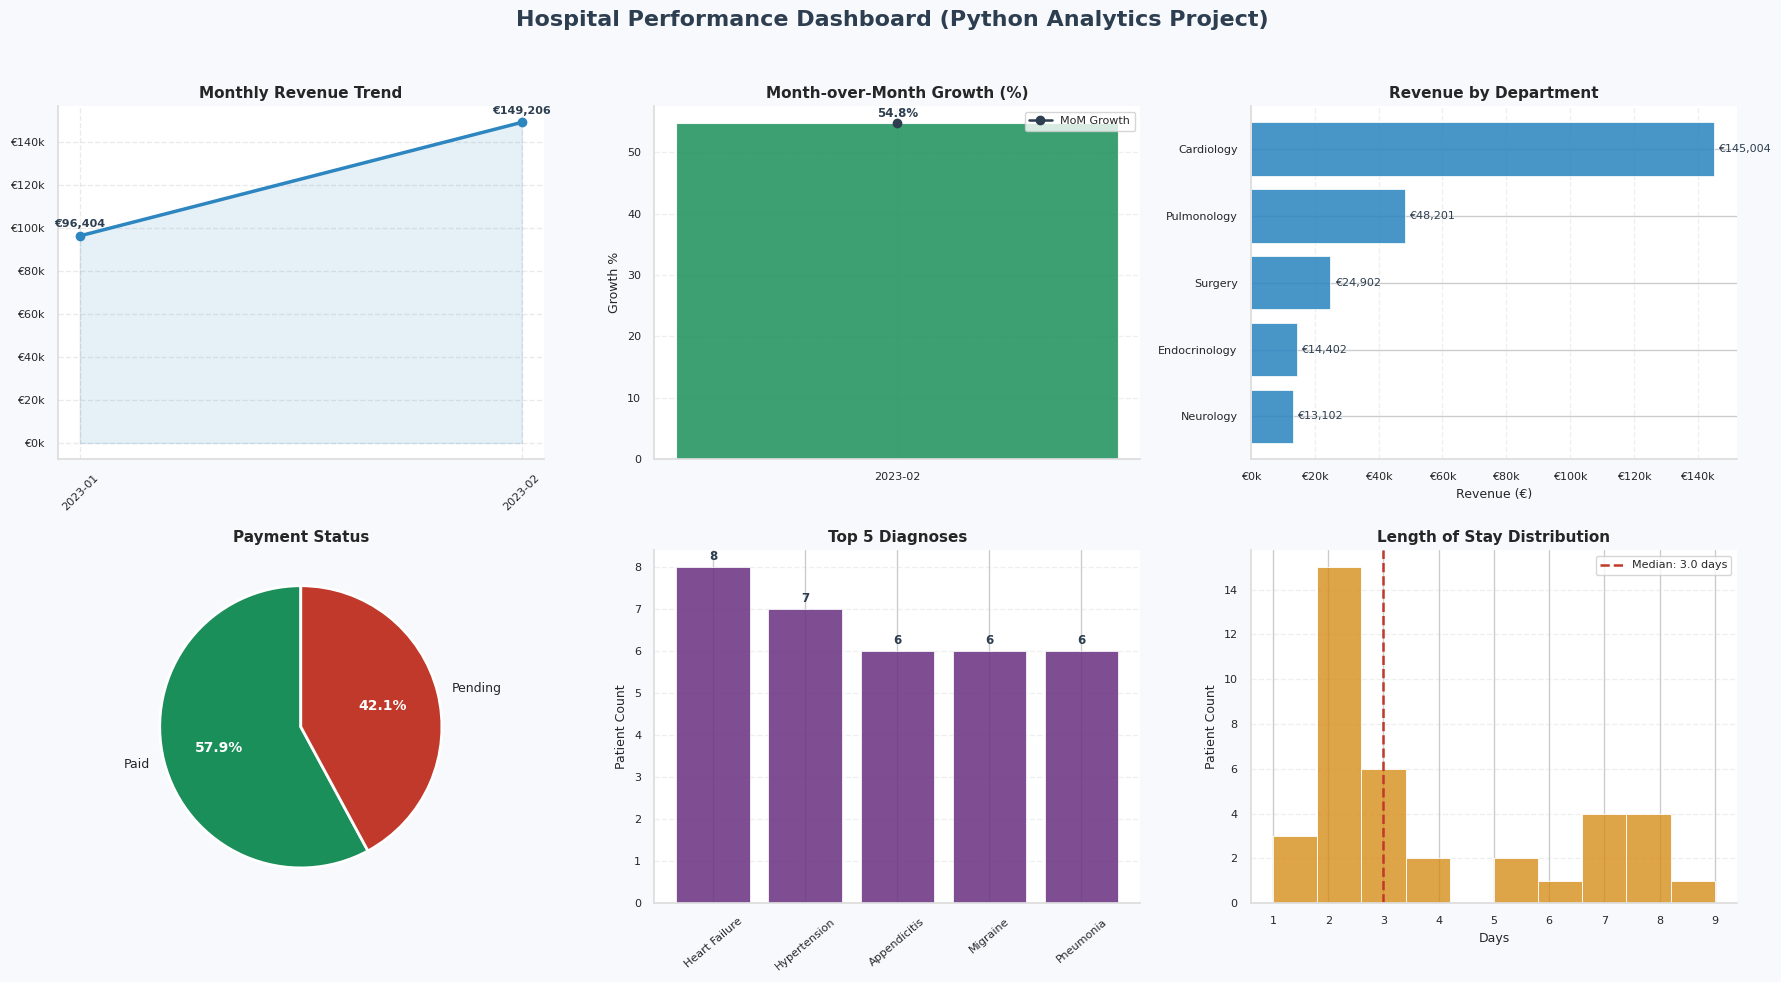

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("cleaned_hospital_data.csv")
df['admission_date'] = pd.to_datetime(df['admission_date'])

# -----------------------------
# CREATE TIME FEATURES
# -----------------------------
df['month'] = df['admission_date'].dt.to_period('M')

# -----------------------------
# AGGREGATIONS
# -----------------------------
monthly = df.groupby('month')['bill_amount'].sum()
monthly.index = monthly.index.astype(str)

mom_growth = monthly.pct_change() * 100
mom_growth = mom_growth.dropna()

# Moving Average Trendline (only meaningful with 3+ points)
mom_trend = mom_growth.rolling(window=3, min_periods=2).mean()

dept = df.groupby('department')['bill_amount'].sum().sort_values()
diagnosis = df['diagnosis'].value_counts().head(5)

# -----------------------------
# UNIFIED COLOR PALETTE
# -----------------------------
PRIMARY   = '#2E86C1'   # blue  — revenue / main metric
POSITIVE  = '#1A8F5A'   # green — growth / paid
NEGATIVE  = '#C0392B'   # red   — pending / decline
NEUTRAL   = '#6C3483'   # purple — clinical/diagnoses
ACCENT    = '#D4860A'   # amber — operational / stay
DARK      = '#2C3E50'   # near-black — lines / text

# -----------------------------
# STYLE
# -----------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor':  '#F7F9FC',
    'axes.facecolor':    '#FFFFFF',
    'axes.edgecolor':    '#DDDDDD',
    'axes.titleweight':  'bold',
    'axes.titlesize':    11,
    'axes.labelsize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'font.family':       'sans-serif',
})

# -----------------------------
# DASHBOARD LAYOUT
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#F7F9FC')
fig.suptitle(
    "Hospital Performance Dashboard (Python Analytics Project)",
    fontsize=16,
    fontweight='bold',
    color=DARK,
    y=0.98
)

# ─────────────────────────────
# 1. MONTHLY REVENUE TREND
# ─────────────────────────────
ax = axes[0, 0]
ax.plot(monthly.index, monthly.values,
        marker='o', linewidth=2.5, color=PRIMARY, zorder=3)
ax.fill_between(monthly.index, monthly.values,
                color=PRIMARY, alpha=0.12)

# Value labels on each point
for x, y in zip(monthly.index, monthly.values):
    ax.text(x, y + monthly.values.max() * 0.02,
            f"€{y:,.0f}", ha='center', va='bottom',
            fontsize=8, color=DARK, fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1000:.0f}k"))
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle='--', alpha=0.4)

# ─────────────────────────────
# 2. MOM GROWTH + TRENDLINE
# Note: trendline only drawn when 3+ months of data exist
# ─────────────────────────────
ax = axes[0, 1]
colors_bar = [POSITIVE if x > 0 else NEGATIVE for x in mom_growth]
bars = ax.bar(mom_growth.index, mom_growth.values,
              color=colors_bar, edgecolor='white',
              linewidth=0.8, alpha=0.85, zorder=2)

ax.plot(mom_growth.index, mom_growth.values,
        color=DARK, marker='o', linewidth=1.8,
        label='MoM Growth', zorder=3)

# Only show trendline if it has meaningful values (3+ months)
valid_trend = mom_trend.dropna()
if len(valid_trend) >= 2:
    ax.plot(valid_trend.index, valid_trend.values,
            color=ACCENT, linestyle='--', linewidth=2.2,
            label='Trendline (3-mo MA)', zorder=3)

ax.axhline(0, color=DARK, linewidth=0.8, linestyle='-')

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            h + (0.5 if h >= 0 else -1.5),
            f"{h:.1f}%", ha='center',
            va='bottom' if h >= 0 else 'top',
            fontsize=8.5, fontweight='bold', color=DARK)

ax.set_title("Month-over-Month Growth (%)")
ax.set_ylabel("Growth %")
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.3)

# ─────────────────────────────
# 3. REVENUE BY DEPARTMENT
# ─────────────────────────────
ax = axes[0, 2]
bars_dept = ax.barh(dept.index, dept.values,
                    color=PRIMARY, edgecolor='white',
                    linewidth=0.6, alpha=0.88)

# Value labels
for bar in bars_dept:
    w = bar.get_width()
    ax.text(w + dept.values.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f"€{w:,.0f}", va='center', fontsize=8, color=DARK)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1000:.0f}k"))
ax.set_title("Revenue by Department")
ax.set_xlabel("Revenue (€)")
ax.grid(True, linestyle='--', alpha=0.3, axis='x')

# ─────────────────────────────
# 4. PAYMENT STATUS
# ─────────────────────────────
ax = axes[1, 0]
payment_counts = df['payment_status'].value_counts()

wedges, texts, autotexts = ax.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    colors=[POSITIVE, NEGATIVE],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title("Payment Status")
ax.set_ylabel("")

# ─────────────────────────────
# 5. TOP DIAGNOSES
# ─────────────────────────────
ax = axes[1, 1]
bars_diag = ax.bar(diagnosis.index, diagnosis.values,
                   color=NEUTRAL, edgecolor='white',
                   linewidth=0.6, alpha=0.88)

for bar in bars_diag:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1,
            str(int(h)), ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color=DARK)

ax.set_title("Top 5 Diagnoses")
ax.set_ylabel("Patient Count")
ax.tick_params(axis='x', rotation=40)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')

# ─────────────────────────────
# 6. LENGTH OF STAY
# ─────────────────────────────
ax = axes[1, 2]
sns.histplot(df['length_of_stay'], bins=10, ax=ax,
             color=ACCENT, edgecolor='white', linewidth=0.6)

median_stay = df['length_of_stay'].median()
ax.axvline(median_stay, color=NEGATIVE, linestyle='--',
           linewidth=1.8, label=f'Median: {median_stay:.1f} days')

ax.set_title("Length of Stay Distribution")
ax.set_xlabel("Days")
ax.set_ylabel("Patient Count")
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')

# -----------------------------
# FINAL LAYOUT
# -----------------------------
sns.despine(left=False, bottom=False)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig("hospital_dashboard_pro.png", dpi=300, bbox_inches='tight')
plt.show()

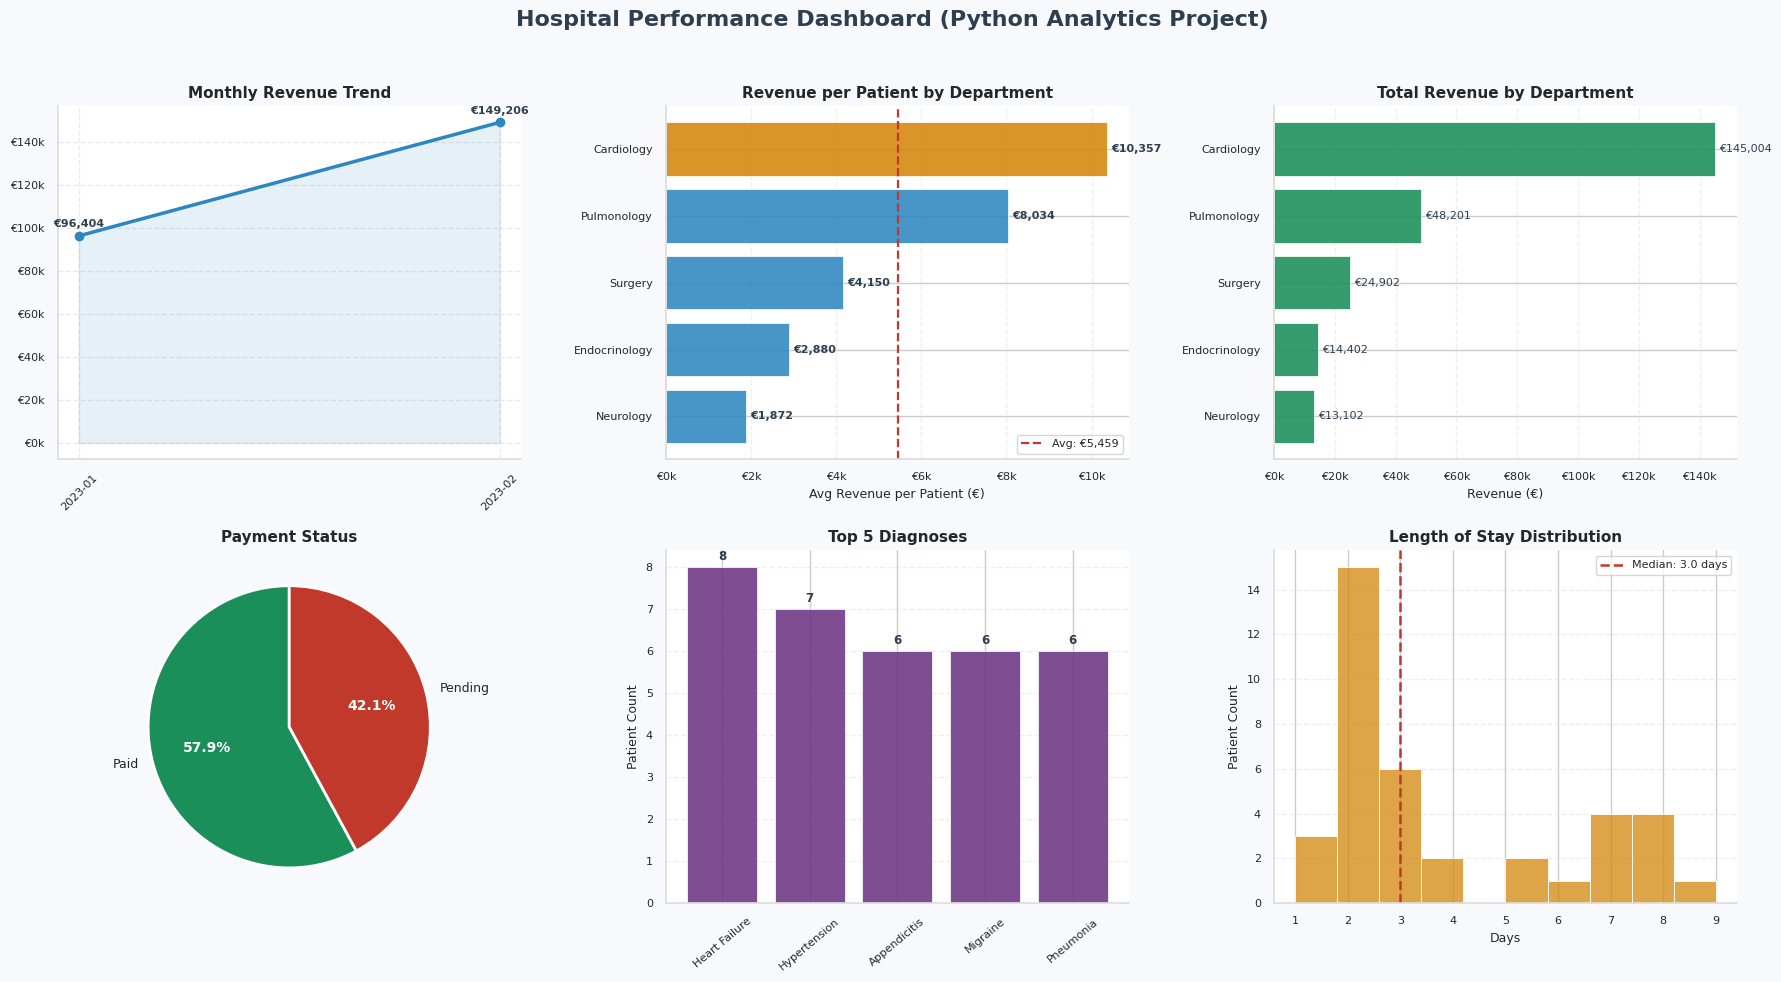

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("cleaned_hospital_data.csv")
df['admission_date'] = pd.to_datetime(df['admission_date'])

# -----------------------------
# CREATE TIME FEATURES
# -----------------------------
df['month'] = df['admission_date'].dt.to_period('M')

# -----------------------------
# AGGREGATIONS
# -----------------------------
monthly = df.groupby('month')['bill_amount'].sum()
monthly.index = monthly.index.astype(str)

dept = df.groupby('department')['bill_amount'].sum().sort_values()
diagnosis = df['diagnosis'].value_counts().head(5)

# 🔥 NEW: Revenue per Patient by Department
dept_revenue = df.groupby('department')['bill_amount'].sum()
dept_count   = df.groupby('department')['bill_amount'].count()
dept_rev_per_patient = (dept_revenue / dept_count).sort_values()

# -----------------------------
# UNIFIED COLOR PALETTE
# -----------------------------
PRIMARY  = '#2E86C1'   # blue  — revenue / main metric
POSITIVE = '#1A8F5A'   # green — growth / paid
NEGATIVE = '#C0392B'   # red   — pending / decline
NEUTRAL  = '#6C3483'   # purple — clinical / diagnoses
ACCENT   = '#D4860A'   # amber — operational / stay
DARK     = '#2C3E50'   # near-black — lines / text

# -----------------------------
# STYLE
# -----------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': '#F7F9FC',
    'axes.facecolor':   '#FFFFFF',
    'axes.edgecolor':   '#DDDDDD',
    'axes.titleweight': 'bold',
    'axes.titlesize':   11,
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
    'font.family':      'sans-serif',
})

# -----------------------------
# DASHBOARD LAYOUT
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#F7F9FC')
fig.suptitle(
    "Hospital Performance Dashboard (Python Analytics Project)",
    fontsize=16,
    fontweight='bold',
    color=DARK,
    y=0.98
)

# ─────────────────────────────
# 1. MONTHLY REVENUE TREND
# ─────────────────────────────
ax = axes[0, 0]
ax.plot(monthly.index, monthly.values,
        marker='o', linewidth=2.5, color=PRIMARY, zorder=3)
ax.fill_between(monthly.index, monthly.values,
                color=PRIMARY, alpha=0.12)

for x, y in zip(monthly.index, monthly.values):
    ax.text(x, y + monthly.values.max() * 0.02,
            f"€{y:,.0f}", ha='center', va='bottom',
            fontsize=8, color=DARK, fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1000:.0f}k"))
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle='--', alpha=0.4)

# ─────────────────────────────
# 2. REVENUE PER PATIENT BY DEPARTMENT (replaces MoM Growth)
# ─────────────────────────────
ax = axes[0, 1]

# Color bars: highlight top performer
bar_colors = [ACCENT if v == dept_rev_per_patient.max()
              else PRIMARY for v in dept_rev_per_patient.values]

bars = ax.barh(dept_rev_per_patient.index,
               dept_rev_per_patient.values,
               color=bar_colors,
               edgecolor='white',
               linewidth=0.6,
               alpha=0.88)

# Value labels
for bar in bars:
    w = bar.get_width()
    ax.text(w + dept_rev_per_patient.values.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"€{w:,.0f}",
            va='center', fontsize=8, color=DARK, fontweight='bold')

# Avg line
avg = dept_rev_per_patient.mean()
ax.axvline(avg, color=NEGATIVE, linestyle='--',
           linewidth=1.6, label=f'Avg: €{avg:,.0f}')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1000:.0f}k"))
ax.set_title("Revenue per Patient by Department")
ax.set_xlabel("Avg Revenue per Patient (€)")
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.3, axis='x')

# ─────────────────────────────
# 3. REVENUE BY DEPARTMENT
# ─────────────────────────────
ax = axes[0, 2]
bars_dept = ax.barh(dept.index, dept.values,
                    color=POSITIVE, edgecolor='white',
                    linewidth=0.6, alpha=0.88)

for bar in bars_dept:
    w = bar.get_width()
    ax.text(w + dept.values.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"€{w:,.0f}", va='center', fontsize=8, color=DARK)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1000:.0f}k"))
ax.set_title("Total Revenue by Department")
ax.set_xlabel("Revenue (€)")
ax.grid(True, linestyle='--', alpha=0.3, axis='x')

# ─────────────────────────────
# 4. PAYMENT STATUS
# ─────────────────────────────
ax = axes[1, 0]
payment_counts = df['payment_status'].value_counts()

wedges, texts, autotexts = ax.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    colors=[POSITIVE, NEGATIVE],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title("Payment Status")
ax.set_ylabel("")

# ─────────────────────────────
# 5. TOP DIAGNOSES
# ─────────────────────────────
ax = axes[1, 1]
bars_diag = ax.bar(diagnosis.index, diagnosis.values,
                   color=NEUTRAL, edgecolor='white',
                   linewidth=0.6, alpha=0.88)

for bar in bars_diag:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1,
            str(int(h)), ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color=DARK)

ax.set_title("Top 5 Diagnoses")
ax.set_ylabel("Patient Count")
ax.tick_params(axis='x', rotation=40)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')

# ─────────────────────────────
# 6. LENGTH OF STAY
# ─────────────────────────────
ax = axes[1, 2]
sns.histplot(df['length_of_stay'], bins=10, ax=ax,
             color=ACCENT, edgecolor='white', linewidth=0.6)

median_stay = df['length_of_stay'].median()
ax.axvline(median_stay, color=NEGATIVE, linestyle='--',
           linewidth=1.8, label=f'Median: {median_stay:.1f} days')

ax.set_title("Length of Stay Distribution")
ax.set_xlabel("Days")
ax.set_ylabel("Patient Count")
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')

# -----------------------------
# FINAL LAYOUT
# -----------------------------
sns.despine(left=False, bottom=False)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig("hospital_dashboard_pro.png", dpi=300, bbox_inches='tight')
plt.show()